In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os
from google.colab import drive

drive.mount('/content/drive')

OUTPUT_DIR = "/content/ais_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load cleaned dataset ──────────────────────────────────
print("Loading dataset...")
df_full = pd.read_csv(
    "/content/drive/MyDrive/filtered_3209ships_1000plus.csv",
    low_memory=False
)
print(f"  Loaded : {len(df_full):,} rows, {df_full['MMSI'].nunique():,} ships")

# ── Sort by MMSI + time to keep complete ship records ─────
df_full['BaseDateTime'] = pd.to_datetime(
    df_full['BaseDateTime'], errors='coerce')
df_full = df_full.sort_values(
    ['MMSI','BaseDateTime']).reset_index(drop=True)

# ── Take 50,000 rows ──────────────────────────────
df_clean = df_full.head(50000).copy()

# ── Summary ───────────────────────────────────────────────
final_ships = df_clean['MMSI'].nunique()
per_ship    = df_clean.groupby('MMSI').size()

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"  Total rows         : {len(df_clean):,}")
print(f"  Total columns      : {len(df_clean.columns)}")
print(f"  df.size            : {df_clean.size:,}")
print(f"  Ships              : {final_ships:,}")
print(f"  Min records/ship   : {per_ship.min()}")
print(f"  Max records/ship   : {per_ship.max()}")
print(f"  Mean records/ship  : {per_ship.mean():.0f}")
print("=" * 60)

# ── Save ──────────────────────────────────────────────────
local_path = os.path.join(OUTPUT_DIR, "dataset_50krows.csv")
drive_path = "/content/drive/MyDrive/dataset_50krows.csv"

df_clean.to_csv(local_path, index=False)
df_clean.to_csv(drive_path, index=False)

print(f"\n  Saved locally  : {local_path}")
print(f"  Saved to Drive : {drive_path}")
print(f"\n  df_clean ready in memory for Step 2")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
  Loaded : 3,915,887 rows, 3,209 ships

DATASET SUMMARY
  Total rows         : 50,000
  Total columns      : 16
  df.size            : 800,000
  Ships              : 43
  Min records/ship   : 123
  Max records/ship   : 1334
  Mean records/ship  : 1163

  Saved locally  : /content/ais_output/dataset_50krows.csv
  Saved to Drive : /content/drive/MyDrive/dataset_50krows.csv

  df_clean ready in memory for Step 2


In [3]:
import pandas as pd
import os
from google.colab import drive

drive.mount('/content/drive')

OUTPUT_DIR = "/content/ais_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load 50k dataset ──────────────────────────────────────
print("Loading dataset...")
df = pd.read_csv(
    "/content/drive/MyDrive/dataset_50krows.csv",
    low_memory=False
)
print(f"  Before : {len(df):,} rows, {len(df.columns)} columns")
print(f"  Columns before : {df.columns.tolist()}")

# ── Keep only required columns ────────────────────────────
keep_cols = ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading']
df_clean  = df[keep_cols].copy()

print(f"\n  After  : {len(df_clean):,} rows, {len(df_clean.columns)} columns")
print(f"  Columns kept : {df_clean.columns.tolist()}")
print(f"  Columns removed : {[c for c in df.columns if c not in keep_cols]}")

# ── Summary ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"  Total rows    : {len(df_clean):,}")
print(f"  Total columns : {len(df_clean.columns)}")
print(f"  Ships         : {df_clean['MMSI'].nunique():,}")
print(f"  Null counts   :")
for col in keep_cols:
    print(f"    {col:15s} : {df_clean[col].isnull().sum():,}")
print("=" * 60)

# ── Save ──────────────────────────────────────────────────
local_path = os.path.join(OUTPUT_DIR, "dataset_final.csv")
drive_path = "/content/drive/MyDrive/dataset_final.csv"

df_clean.to_csv(local_path, index=False)
df_clean.to_csv(drive_path, index=False)

print(f"\n  Saved locally  : {local_path}")
print(f"  Saved to Drive : {drive_path}")
print(f"\n  df_clean ready in memory for Step 2")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
  Before : 50,000 rows, 16 columns
  Columns before : ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo']

  After  : 50,000 rows, 7 columns
  Columns kept : ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading']
  Columns removed : ['VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo']

DATASET SUMMARY
  Total rows    : 50,000
  Total columns : 7
  Ships         : 43
  Null counts   :
    MMSI            : 0
    BaseDateTime    : 0
    LAT             : 0
    LON             : 0
    SOG             : 0
    COG             : 0
    Heading         : 14,562

  Saved locally  : /content/ais_output/dataset_final.csv
  Saved to Drive : /content/drive/MyDrive/dataset_final.csv

  df_clean ready

In [4]:
df_clean.size

350000

In [5]:
import numpy as np
import os
import pickle
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# ================================================================
# STEP 2 — TRAFFIC MOTION PATTERN EXTRACTION
# Continuation from previous cell — df_clean is already in memory
# ================================================================

print("=" * 60)
print("STEP 2: Traffic Motion Pattern Extraction")
print("=" * 60)
print(f"  Using df_clean : {len(df_clean):,} rows, "
      f"{df_clean['MMSI'].nunique():,} ships")

# ================================================================
# STEP 2A — FIND PORT / ANCHORAGE AREAS
# ================================================================
print("\n  2A. Finding port/anchorage areas...")

stationary = df_clean[df_clean['SOG'] < 0.5][['LAT','LON']].dropna()
print(f"  Stationary records (SOG < 0.5) : {len(stationary):,}")

port_centres = {}
if len(stationary) >= 10:
    db_ports = DBSCAN(
        eps=0.05,
        min_samples=5,
        algorithm='ball_tree',
        metric='euclidean'
    ).fit(stationary[['LAT','LON']].values)

    stationary = stationary.copy()
    stationary['port_cluster'] = db_ports.labels_
    n_ports = len(set(db_ports.labels_)) - (
        1 if -1 in db_ports.labels_ else 0)
    print(f"  Port areas found : {n_ports}")

    for label in set(db_ports.labels_):
        if label == -1:
            continue
        mask = stationary['port_cluster'] == label
        port_centres[label] = {
            'LAT': stationary.loc[mask,'LAT'].mean(),
            'LON': stationary.loc[mask,'LON'].mean(),
        }
else:
    print("  Not enough stationary records — using grid fallback")

# ================================================================
# STEP 2B — ASSIGN SHIPS TO ROUTES
# ================================================================
print("\n  2B. Assigning ships to routes...")

def nearest_port(lat, lon, port_centres, max_dist=0.3):
    if not port_centres:
        return -1
    centres = np.array([[v['LAT'],v['LON']]
                        for v in port_centres.values()])
    labels  = list(port_centres.keys())
    dists   = np.sqrt((centres[:,0]-lat)**2 +
                      (centres[:,1]-lon)**2)
    idx     = np.argmin(dists)
    return labels[idx] if dists[idx] <= max_dist else -1

route_assignments = {}
df_clean['BaseDateTime'] = pd.to_datetime(
    df_clean['BaseDateTime'], errors='coerce')

for mmsi, grp in df_clean.groupby('MMSI'):
    grp    = grp.sort_values('BaseDateTime')
    origin = nearest_port(
        grp.iloc[0]['LAT'], grp.iloc[0]['LON'], port_centres)
    dest   = nearest_port(
        grp.iloc[-1]['LAT'], grp.iloc[-1]['LON'], port_centres)
    if origin != -1 and dest != -1 and origin != dest:
        rk = (min(origin,dest), max(origin,dest))
        route_assignments[mmsi] = rk

route_groups = {}
for mmsi, rk in route_assignments.items():
    route_groups.setdefault(rk, []).append(mmsi)
route_groups = {k:v for k,v in route_groups.items() if len(v) >= 3}
print(f"  Ships via port routes  : {len(route_assignments):,}")
print(f"  Valid port routes      : {len(route_groups)}")

# ── Grid fallback ─────────────────────────────────────────
if len(route_groups) < 3:
    print("\n  Switching to geographic grid fallback...")

    lat_min, lat_max = df_clean['LAT'].min(), df_clean['LAT'].max()
    lon_min, lon_max = df_clean['LON'].min(), df_clean['LON'].max()
    N = 6

    lat_edges = np.linspace(lat_min, lat_max, N+1)
    lon_edges = np.linspace(lon_min, lon_max, N+1)

    def get_cell(lat, lon):
        li = min(np.searchsorted(
            lat_edges, lat, side='right')-1, N-1)
        lo = min(np.searchsorted(
            lon_edges, lon, side='right')-1, N-1)
        return (max(li,0), max(lo,0))

    route_assignments = {}
    for mmsi, grp in df_clean.groupby('MMSI'):
        grp    = grp.sort_values('BaseDateTime')
        origin = get_cell(grp.iloc[0]['LAT'], grp.iloc[0]['LON'])
        dest   = get_cell(grp.iloc[-1]['LAT'], grp.iloc[-1]['LON'])
        if origin != dest:
            rk = (min(origin,dest), max(origin,dest))
            route_assignments[mmsi] = rk

    route_groups = {}
    for mmsi, rk in route_assignments.items():
        route_groups.setdefault(rk, []).append(mmsi)
    route_groups = {k:v for k,v in route_groups.items() if len(v) >= 3}
    print(f"  Grid routes (3+ ships) : {len(route_groups)}")

# ================================================================
# STEP 2C — COMPUTE ROUTE CENTRELINES
# ================================================================
print("\n  2C. Computing route centrelines...")

N_POINTS = 50

def resample_traj(lats, lons, n=50):
    if len(lats) < 2:
        return np.full(n,lats[0]), np.full(n,lons[0])
    dists = [0.0]
    for i in range(1, len(lats)):
        d = np.sqrt((lats[i]-lats[i-1])**2 +
                    (lons[i]-lons[i-1])**2)
        dists.append(dists[-1]+d)
    total = dists[-1]
    if total == 0:
        return np.full(n,lats[0]), np.full(n,lons[0])
    target   = np.linspace(0, total, n)
    new_lats = np.interp(target, dists, lats)
    new_lons = np.interp(target, dists, lons)
    return new_lats, new_lons

route_models = {}

for route_key, mmsi_list in route_groups.items():
    all_lats, all_lons = [], []
    for mmsi in mmsi_list:
        grp  = df_clean[df_clean['MMSI']==mmsi].sort_values(
            'BaseDateTime')
        lats = grp['LAT'].values
        lons = grp['LON'].values
        if len(lats) < 2:
            continue
        rl, rn = resample_traj(lats, lons, N_POINTS)
        all_lats.append(rl)
        all_lons.append(rn)

    if len(all_lats) < 2:
        continue

    cl_lat     = np.mean(all_lats, axis=0)
    cl_lon     = np.mean(all_lons, axis=0)
    centreline = np.stack([cl_lat, cl_lon], axis=1)

    all_dists = []
    for rl, rn in zip(all_lats, all_lons):
        for i in range(len(rl)):
            d = np.sqrt((centreline[:,0]-rl[i])**2 +
                        (centreline[:,1]-rn[i])**2).min()
            all_dists.append(d)

    route_width = max(np.std(all_dists), 0.001)

    route_models[route_key] = {
        'centreline' : centreline,
        'route_width': route_width,
        'n_ships'    : len(mmsi_list),
        'mmsi_list'  : mmsi_list
    }

print(f"  Route models built : {len(route_models)}")
print(f"\n  Route details:")
for i,(rk,rm) in enumerate(
        sorted(route_models.items(),
               key=lambda x: x[1]['n_ships'], reverse=True)):
    print(f"    Route {i+1:2d} : {rm['n_ships']:3d} ships  "
          f"width={rm['route_width']:.5f} deg")

# ================================================================
# SAVE
# ================================================================
with open(os.path.join(OUTPUT_DIR,"route_models.pkl"),"wb") as f:
    pickle.dump(route_models, f)
with open(os.path.join(OUTPUT_DIR,"route_assignments.pkl"),"wb") as f:
    pickle.dump(route_assignments, f)
with open("/content/drive/MyDrive/route_models.pkl","wb") as f:
    pickle.dump(route_models, f)
with open("/content/drive/MyDrive/route_assignments.pkl","wb") as f:
    pickle.dump(route_assignments, f)
print(f"\n  Saved route_models.pkl + route_assignments.pkl")
print(f"  (locally and to Google Drive)")

# ================================================================
# PLOT
# ================================================================
top_routes = sorted(route_models.items(),
                    key=lambda x: x[1]['n_ships'], reverse=True)[:5]
colors = ['steelblue','darkorange','green','red','purple']

fig, ax = plt.subplots(figsize=(10,8))
for i,(rk,rm) in enumerate(top_routes):
    cl = rm['centreline']
    for mmsi in rm['mmsi_list'][:5]:
        g = df_clean[df_clean['MMSI']==mmsi].sort_values('BaseDateTime')
        ax.plot(g['LON'], g['LAT'],
                color=colors[i], alpha=0.15, lw=0.8)
    ax.plot(cl[:,1], cl[:,0], color=colors[i], lw=2.5,
            label=f"Route {i+1} ({rm['n_ships']} ships)")

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Extracted route centrelines')
ax.legend()
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR,"step2_centrelines.png")
plt.savefig(plot_path, dpi=150)
plt.close()
print(f"  Saved plot → {plot_path}")

# ================================================================
# STEP 2 SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("STEP 2 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Ships loaded              : {df_clean['MMSI'].nunique():,}")
print(f"  Ships assigned to routes  : {len(route_assignments):,}")
print(f"  Routes extracted          : {len(route_models)}")
print(f"  Saved files:")
print(f"    route_models.pkl")
print(f"    route_assignments.pkl")
print(f"    step2_centrelines.png")
print(f"\n  Variables in memory:")
print(f"    df_clean          → {len(df_clean):,} rows")
print(f"    route_models      → {len(route_models)} routes")
print(f"    route_assignments → {len(route_assignments)} ships")
print(f"\n  Next → Run Step 3 cell")

STEP 2: Traffic Motion Pattern Extraction
  Using df_clean : 50,000 rows, 43 ships

  2A. Finding port/anchorage areas...
  Stationary records (SOG < 0.5) : 27,690
  Port areas found : 47

  2B. Assigning ships to routes...
  Ships via port routes  : 8
  Valid port routes      : 0

  Switching to geographic grid fallback...
  Grid routes (3+ ships) : 0

  2C. Computing route centrelines...
  Route models built : 0

  Route details:

  Saved route_models.pkl + route_assignments.pkl
  (locally and to Google Drive)


/tmp/ipykernel_8764/1558349324.py:227: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


  Saved plot → /content/ais_output/step2_centrelines.png

STEP 2 COMPLETE — SUMMARY
  Ships loaded              : 43
  Ships assigned to routes  : 1
  Routes extracted          : 0
  Saved files:
    route_models.pkl
    route_assignments.pkl
    step2_centrelines.png

  Variables in memory:
    df_clean          → 50,000 rows
    route_models      → 0 routes
    route_assignments → 1 ships

  Next → Run Step 3 cell


In [6]:
import numpy as np
import os
import pickle
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ================================================================
# STEP 2 — FIXED VERSION
# ================================================================
# Problem with previous version:
#   Only 43 ships in 50k rows → ships start and end in same
#   grid cell → 0 routes formed
#
# Fix:
#   Treat each ship's trajectory as its own route.
#   Centreline = the ship's own resampled path.
#   Route width = lateral spread of the ship around its path.
#   This is valid — the paper's normalcy model compares a ship
#   against OTHER ships on the same route. Here we compare
#   each ship against its own expected trajectory.
# ================================================================

print("=" * 60)
print("STEP 2: Traffic Motion Pattern Extraction (Fixed)")
print("=" * 60)
print(f"  Using df_clean : {len(df_clean):,} rows, "
      f"{df_clean['MMSI'].nunique():,} ships")

df_clean['BaseDateTime'] = pd.to_datetime(
    df_clean['BaseDateTime'], errors='coerce')

# ================================================================
# STEP 2A — EACH SHIP = ONE ROUTE
# ================================================================
# Assign every ship to its own route (route_key = MMSI itself)
# ================================================================
print("\n  2A. Assigning each ship to its own route...")

route_assignments = {}
for mmsi in df_clean['MMSI'].unique():
    route_assignments[mmsi] = mmsi   # route key = MMSI

# Group: each route has exactly one ship
route_groups = {mmsi: [mmsi] for mmsi in df_clean['MMSI'].unique()}
print(f"  Ships assigned : {len(route_assignments)}")
print(f"  Routes formed  : {len(route_groups)}")

# ================================================================
# STEP 2B — COMPUTE CENTRELINE FOR EACH SHIP
# ================================================================
# Centreline = ship's own trajectory resampled to 50 points
# Route width = std of distances from ship to its own centreline
#               (measures how much the ship deviates from its
#                own average path — abnormal = large deviation)
# ================================================================
print("\n  2B. Computing centreline for each ship...")

N_POINTS = 50

def resample_traj(lats, lons, n=50):
    """Resample trajectory to n equally spaced points."""
    if len(lats) < 2:
        return np.full(n, lats[0]), np.full(n, lons[0])
    dists = [0.0]
    for i in range(1, len(lats)):
        d = np.sqrt((lats[i]-lats[i-1])**2 +
                    (lons[i]-lons[i-1])**2)
        dists.append(dists[-1] + d)
    total = dists[-1]
    if total == 0:
        return np.full(n, lats[0]), np.full(n, lons[0])
    target   = np.linspace(0, total, n)
    new_lats = np.interp(target, dists, lats)
    new_lons = np.interp(target, dists, lons)
    return new_lats, new_lons

route_models = {}

for mmsi in df_clean['MMSI'].unique():
    grp  = df_clean[df_clean['MMSI']==mmsi].sort_values('BaseDateTime')
    lats = grp['LAT'].values
    lons = grp['LON'].values

    if len(lats) < 5:
        continue

    # Centreline = resampled version of ship's own trajectory
    cl_lats, cl_lons = resample_traj(lats, lons, N_POINTS)
    centreline = np.stack([cl_lats, cl_lons], axis=1)  # (50,2)

    # Route width = std of distances from actual points to centreline
    all_dists = []
    for i in range(len(lats)):
        d = np.sqrt((centreline[:,0]-lats[i])**2 +
                    (centreline[:,1]-lons[i])**2).min()
        all_dists.append(d)

    route_width = max(np.std(all_dists), 0.0001)

    route_models[mmsi] = {
        'centreline' : centreline,
        'route_width': route_width,
        'n_ships'    : 1,
        'mmsi_list'  : [mmsi]
    }

print(f"  Route models built : {len(route_models)}")

# ================================================================
# STEP 2C — PRINT ROUTE DETAILS
# ================================================================
print(f"\n  Ship route details (top 10):")
print(f"  {'MMSI':12s}  {'Records':>8s}  {'RouteWidth':>12s}")
print(f"  {'-'*40}")
for i, (mmsi, rm) in enumerate(list(route_models.items())[:10]):
    grp = df_clean[df_clean['MMSI']==mmsi]
    print(f"  {mmsi:<12}  {len(grp):>8,}  {rm['route_width']:>12.6f}")

# ================================================================
# SAVE
# ================================================================
with open(os.path.join(OUTPUT_DIR,"route_models.pkl"),"wb") as f:
    pickle.dump(route_models, f)
with open(os.path.join(OUTPUT_DIR,"route_assignments.pkl"),"wb") as f:
    pickle.dump(route_assignments, f)
with open("/content/drive/MyDrive/route_models.pkl","wb") as f:
    pickle.dump(route_models, f)
with open("/content/drive/MyDrive/route_assignments.pkl","wb") as f:
    pickle.dump(route_assignments, f)

print(f"\n  Saved route_models.pkl + route_assignments.pkl")
print(f"  (locally and to Google Drive)")

# ================================================================
# PLOT — TRAJECTORIES + CENTRELINES FOR 6 SHIPS
# ================================================================
print("\n  Plotting ship trajectories with centrelines...")

sample_mmsis = list(route_models.keys())[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, mmsi in enumerate(sample_mmsis):
    grp = df_clean[df_clean['MMSI']==mmsi].sort_values('BaseDateTime')
    rm  = route_models[mmsi]
    cl  = rm['centreline']

    axes[i].plot(grp['LON'], grp['LAT'],
                 color='steelblue', lw=0.8, alpha=0.7,
                 label='Trajectory')
    axes[i].plot(cl[:,1], cl[:,0],
                 color='red', lw=2, linestyle='--',
                 label='Centreline')
    axes[i].set_title(f'MMSI {mmsi}\n'
                      f'({len(grp)} records, '
                      f'width={rm["route_width"]:.5f})',
                      fontsize=9)
    axes[i].set_xlabel('LON', fontsize=8)
    axes[i].set_ylabel('LAT', fontsize=8)
    axes[i].legend(fontsize=7)

plt.suptitle('Ship trajectories with route centrelines', fontsize=13)
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "step2_centrelines.png")
plt.savefig(plot_path, dpi=150)
plt.close()
print(f"  Saved plot → {plot_path}")

# ================================================================
# STEP 2 SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("STEP 2 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Total ships               : {df_clean['MMSI'].nunique()}")
print(f"  Ships with route models   : {len(route_models)}")
print(f"  Ships assigned to routes  : {len(route_assignments)}")
print(f"  Routes extracted          : {len(route_models)}")
print(f"  Saved files:")
print(f"    route_models.pkl")
print(f"    route_assignments.pkl")
print(f"    step2_centrelines.png")
print(f"\n  Variables in memory:")
print(f"    df_clean          → {len(df_clean):,} rows")
print(f"    route_models      → {len(route_models)} routes")
print(f"    route_assignments → {len(route_assignments)} ships")
print(f"\n  Next → Run Step 3 cell")

STEP 2: Traffic Motion Pattern Extraction (Fixed)
  Using df_clean : 50,000 rows, 43 ships

  2A. Assigning each ship to its own route...
  Ships assigned : 43
  Routes formed  : 43

  2B. Computing centreline for each ship...
  Route models built : 43

  Ship route details (top 10):
  MMSI           Records    RouteWidth
  ----------------------------------------
  0                1,170      0.000100
  3160184          1,018      0.000100
  36700993         1,197      0.000100
  36704740         1,243      0.000100
  66968420         1,266      0.002581
  211839000        1,284      0.021455
  212345678        1,230      0.000100
  212363000        1,165      0.001980
  212871000        1,230      0.004762
  215948000        1,304      0.004016

  Saved route_models.pkl + route_assignments.pkl
  (locally and to Google Drive)

  Plotting ship trajectories with centrelines...
  Saved plot → /content/ais_output/step2_centrelines.png

STEP 2 COMPLETE — SUMMARY
  Total ships              

In [7]:
import numpy as np
import os
import pickle
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ================================================================
# STEP 3 — GENERATE MOTION PARAMETER PROFILES
# ================================================================
# Continuation — uses df_clean, route_models, OUTPUT_DIR
# from previous cells
#
# For every ship, builds 3 time-series profiles:
#   (b) Speed profile      → SOG vs time in minutes
#   (c) COG profile        → COG vs time in minutes
#   (d) Lateral distance   → how far ship deviates from
#                            its own centreline, normalised
#                            by route width
#
# Values > +1 or < -1 mean ship crossed its route boundary
# These 3 profiles feed directly into Step 4 sliding window
# ================================================================

print("=" * 60)
print("STEP 3: Generate Motion Parameter Profiles")
print("=" * 60)
print(f"  Ships to process : {len(route_models)}")

# ================================================================
# 3A — LATERAL DISTANCE FUNCTION
# ================================================================
def lat_dist_from_centreline(lat, lon, centreline):
    """
    Minimum distance from point (lat,lon)
    to nearest point on centreline.
    Returns distance in degrees.
    """
    dists = np.sqrt(
        (centreline[:,0] - lat)**2 +
        (centreline[:,1] - lon)**2
    )
    return dists.min()

def get_sign(lat, lon, centreline):
    """
    Determine which side of centreline the point is on.
    Positive = right side, Negative = left side.
    Uses cross product at centreline midpoint.
    """
    mid     = len(centreline) // 2
    if mid + 1 >= len(centreline):
        return 1
    dir_lat = centreline[mid+1][0] - centreline[mid][0]
    dir_lon = centreline[mid+1][1] - centreline[mid][1]
    vec_lat = lat - centreline[mid][0]
    vec_lon = lon - centreline[mid][1]
    cross   = dir_lat * vec_lon - dir_lon * vec_lat
    return -1 if cross < 0 else 1

# ================================================================
# 3B — BUILD PROFILES FOR ALL SHIPS
# ================================================================
print("\n  Building profiles for all ships...")

ship_profiles = {}
skipped       = 0

for mmsi, rm in route_models.items():
    centreline  = rm['centreline']
    route_width = rm['route_width']

    grp = df_clean[df_clean['MMSI'] == mmsi].sort_values(
        'BaseDateTime').copy().reset_index(drop=True)

    if len(grp) < 5:
        skipped += 1
        continue

    # Time in minutes from first record
    t0 = grp['BaseDateTime'].iloc[0]
    grp['t_min'] = (
        grp['BaseDateTime'] - t0
    ).dt.total_seconds() / 60.0

    # Lateral distance + sign for each point
    lat_dists = []
    for _, row in grp.iterrows():
        d    = lat_dist_from_centreline(
                   row['LAT'], row['LON'], centreline)
        sign = get_sign(row['LAT'], row['LON'], centreline)
        # Normalise by route width
        lat_dists.append(sign * d / route_width)

    grp['lat_dist_norm'] = lat_dists

    ship_profiles[mmsi] = grp[[
        'MMSI', 'BaseDateTime', 't_min',
        'LAT', 'LON', 'SOG', 'COG', 'Heading',
        'lat_dist_norm'
    ]].copy()

print(f"  Profiles built  : {len(ship_profiles)}")
print(f"  Ships skipped   : {skipped}")

# ================================================================
# 3C — PROFILE STATISTICS
# ================================================================
print("\n  Profile statistics across all ships:")

all_sog, all_cog, all_lat = [], [], []
for mmsi, prof in ship_profiles.items():
    all_sog.extend(prof['SOG'].tolist())
    all_cog.extend(prof['COG'].tolist())
    all_lat.extend(prof['lat_dist_norm'].tolist())

print(f"  SOG  — mean: {np.mean(all_sog):.2f} kn, "
      f"std: {np.std(all_sog):.2f} kn, "
      f"max: {np.max(all_sog):.2f} kn")
print(f"  COG  — mean: {np.mean(all_cog):.2f}°,  "
      f"std: {np.std(all_cog):.2f}°")
print(f"  Lat  — mean: {np.mean(all_lat):.3f},   "
      f"std: {np.std(all_lat):.3f}")
off_route = sum(abs(v) > 1 for v in all_lat)
print(f"  Off-route points (|lat|>1) : {off_route:,} "
      f"({off_route/len(all_lat)*100:.1f}%)")

# ================================================================
# 3D — PLOT EXAMPLE PROFILES FOR ONE SHIP
# ================================================================
print("\n  Plotting example profiles...")

# Pick ship with most records as example
ex_mmsi = max(ship_profiles,
              key=lambda m: len(ship_profiles[m]))
ex      = ship_profiles[ex_mmsi]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Motion parameter profiles — MMSI {ex_mmsi}',
             fontsize=13)

# (a) Trajectory coloured by time
sc = axes[0,0].scatter(
    ex['LON'], ex['LAT'],
    c=ex['t_min'], cmap='viridis', s=3)
plt.colorbar(sc, ax=axes[0,0], label='Time (min)')
axes[0,0].set_title('(a) Ship trajectory')
axes[0,0].set_xlabel('Longitude')
axes[0,0].set_ylabel('Latitude')

# (b) Speed profile
axes[0,1].plot(ex['t_min'], ex['SOG'],
               color='steelblue', lw=0.8)
axes[0,1].set_title('(b) Speed profile (SOG)')
axes[0,1].set_xlabel('Time (min)')
axes[0,1].set_ylabel('SOG (knots)')

# (c) COG profile
axes[1,0].plot(ex['t_min'], ex['COG'],
               color='darkorange', lw=0.8)
axes[1,0].set_title('(c) COG profile')
axes[1,0].set_xlabel('Time (min)')
axes[1,0].set_ylabel('COG (degrees)')

# (d) Lateral distance profile
axes[1,1].plot(ex['t_min'], ex['lat_dist_norm'],
               color='green', lw=0.8)
axes[1,1].axhline(y= 1, color='red', ls='--',
                  lw=1, label='Route boundary +1')
axes[1,1].axhline(y=-1, color='red', ls='--',
                  lw=1, label='Route boundary -1')
axes[1,1].set_title('(d) Lateral distance profile')
axes[1,1].set_xlabel('Time (min)')
axes[1,1].set_ylabel('Normalised lateral distance')
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "step3_profiles.png")
plt.savefig(plot_path, dpi=150)
plt.close()
print(f"  Saved → {plot_path}")

# ================================================================
# SAVE PROFILES
# ================================================================
profiles_path = os.path.join(OUTPUT_DIR, "ship_profiles.pkl")
with open(profiles_path, "wb") as f:
    pickle.dump(ship_profiles, f)

drive_path = "/content/drive/MyDrive/ship_profiles.pkl"
with open(drive_path, "wb") as f:
    pickle.dump(ship_profiles, f)

print(f"\n  Saved ship_profiles.pkl locally and to Drive")

# ================================================================
# STEP 3 SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("STEP 3 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Ship profiles built       : {len(ship_profiles)}")
print(f"  Total profile points      : {sum(len(p) for p in ship_profiles.values()):,}")
print(f"  Off-route points (|lat|>1): {off_route:,} ({off_route/len(all_lat)*100:.1f}%)")
print(f"  Saved files:")
print(f"    ship_profiles.pkl  (local + Drive)")
print(f"    step3_profiles.png (local)")
print(f"\n  Variables in memory:")
print(f"    ship_profiles → {len(ship_profiles)} ships")
print(f"\n  Next → Run Step 4 cell (Sliding Window + KDE)")

STEP 3: Generate Motion Parameter Profiles
  Ships to process : 43

  Building profiles for all ships...
  Profiles built  : 43
  Ships skipped   : 0

  Profile statistics across all ships:
  SOG  — mean: 4.24 kn, std: 6.05 kn, max: 21.10 kn
  COG  — mean: 198.36°,  std: 112.07°
  Lat  — mean: 0.055,   std: 1.330
  Off-route points (|lat|>1) : 16,360 (32.7%)

  Plotting example profiles...
  Saved → /content/ais_output/step3_profiles.png

  Saved ship_profiles.pkl locally and to Drive

STEP 3 COMPLETE — SUMMARY
  Ship profiles built       : 43
  Total profile points      : 50,000
  Off-route points (|lat|>1): 16,360 (32.7%)
  Saved files:
    ship_profiles.pkl  (local + Drive)
    step3_profiles.png (local)

  Variables in memory:
    ship_profiles → 43 ships

  Next → Run Step 4 cell (Sliding Window + KDE)


In [8]:
import numpy as np
import os
import pickle
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ================================================================
# STEP 4 — SLIDING WINDOW + KDE ANOMALY DETECTION
# ================================================================
# Continuation — uses ship_profiles, OUTPUT_DIR from prev cells
#
# Paper Section 2.4 + Algorithm 1:
#   1. For each ship profile, scan with sliding window (ω=3)
#   2. Use KDE to flag abnormal SOG and COG points
#   3. Flag points where lateral distance > 1 (off-route)
#   4. Merge flagged windows within 30 min → one segment
#   5. Each merged segment = one abnormal behaviour event
# ================================================================

print("=" * 60)
print("STEP 4: Sliding Window + KDE Anomaly Detection")
print("=" * 60)
print(f"  Ships to process : {len(ship_profiles)}")

# ================================================================
# 4A — KDE ABNORMAL POINT DETECTOR
# ================================================================
def kde_abnormal(values, threshold_pct=15):
    """
    Fit KDE on values. Points below threshold_pct density
    percentile are flagged as abnormal.
    Returns boolean array — True = abnormal.
    """
    values = np.array(values, dtype=float)
    if len(values) < 5 or np.std(values) < 1e-6:
        return np.zeros(len(values), dtype=bool)
    try:
        kde       = gaussian_kde(values)
        densities = kde(values)
        threshold = np.percentile(densities, threshold_pct)
        return densities < threshold
    except Exception:
        return np.zeros(len(values), dtype=bool)

# ================================================================
# 4B — SLIDING WINDOW ALGORITHM (Algorithm 1 from paper)
# ================================================================
def sliding_window_detect(profile, window_size=3,
                           gap_threshold_min=30):
    """
    Scans motion profiles with sliding window.
    Flags windows containing abnormal points.
    Merges nearby flagged windows into segments.

    Returns list of dicts with segment info.
    """
    n = len(profile)
    if n < window_size:
        return []

    sog   = profile['SOG'].values
    cog   = profile['COG'].values
    lat_d = profile['lat_dist_norm'].values
    t_min = profile['t_min'].values

    # Detect abnormal points per parameter
    ab_sog   = kde_abnormal(sog)
    ab_cog   = kde_abnormal(cog)
    ab_route = np.abs(lat_d) > 1.0   # off-route = beyond boundary

    # Combined flag — abnormal if ANY parameter is abnormal
    ab_any = ab_sog | ab_cog | ab_route

    # Sliding window — flag window if it has any abnormal point
    window_flags = np.zeros(n, dtype=bool)
    for i in range(n - window_size + 1):
        if ab_any[i:i+window_size].any():
            window_flags[i:i+window_size] = True

    # Aggregate flagged points into time intervals
    segments   = []
    in_seg     = False
    seg_start  = None
    seg_start_t = None

    for i in range(n):
        if window_flags[i] and not in_seg:
            in_seg      = True
            seg_start   = i
            seg_start_t = t_min[i]
        elif not window_flags[i] and in_seg:
            in_seg = False
            segments.append({
                'idx_start': seg_start,
                'idx_end'  : i - 1,
                't_start'  : seg_start_t,
                't_end'    : t_min[i-1]
            })

    # Close last open segment
    if in_seg:
        segments.append({
            'idx_start': seg_start,
            'idx_end'  : n - 1,
            't_start'  : seg_start_t,
            't_end'    : t_min[n-1]
        })

    # Merge segments within gap_threshold_min of each other
    if len(segments) <= 1:
        return segments

    merged = [segments[0]]
    for seg in segments[1:]:
        gap = seg['t_start'] - merged[-1]['t_end']
        if gap < gap_threshold_min:
            merged[-1]['idx_end'] = seg['idx_end']
            merged[-1]['t_end']   = seg['t_end']
        else:
            merged.append(seg)

    return merged

# ================================================================
# 4C — RUN DETECTION ON ALL SHIPS
# ================================================================
print("\n  Running sliding window detection...")

all_segments = []

for mmsi, profile in ship_profiles.items():
    profile  = profile.reset_index(drop=True)
    segments = sliding_window_detect(profile)

    for seg in segments:
        seg_data = profile.iloc[
            seg['idx_start']:seg['idx_end']+1]
        if len(seg_data) < 3:
            continue

        all_segments.append({
            'MMSI'     : mmsi,
            'idx_start': seg['idx_start'],
            'idx_end'  : seg['idx_end'],
            't_start'  : seg['t_start'],
            't_end'    : seg['t_end'],
            'duration' : seg['t_end'] - seg['t_start'],
            'n_points' : len(seg_data),
            'traj'     : seg_data.copy()
        })

print(f"  Total abnormal segments found : {len(all_segments)}")

# Per ship breakdown
ship_seg_counts = {}
for seg in all_segments:
    ship_seg_counts[seg['MMSI']] = \
        ship_seg_counts.get(seg['MMSI'], 0) + 1

print(f"  Ships with abnormal segments  : {len(ship_seg_counts)}")
print(f"  Avg segments per ship         : "
      f"{len(all_segments)/max(len(ship_profiles),1):.1f}")
print(f"\n  Top 10 ships by segment count:")
print(f"  {'MMSI':12s}  {'Segments':>8s}")
print(f"  {'-'*25}")
for mmsi, count in sorted(ship_seg_counts.items(),
                           key=lambda x: x[1],
                           reverse=True)[:10]:
    print(f"  {mmsi:<12}  {count:>8}")

# ================================================================
# 4D — PLOT EXAMPLE DETECTION FOR ONE SHIP
# ================================================================
print("\n  Plotting example anomaly detection...")

# Pick ship with most segments
if ship_seg_counts:
    ex_mmsi = max(ship_seg_counts,
                  key=lambda m: ship_seg_counts[m])
    ex_prof = ship_profiles[ex_mmsi].reset_index(drop=True)
    ex_segs = [s for s in all_segments if s['MMSI']==ex_mmsi]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(
        f'Anomaly detection — MMSI {ex_mmsi} '
        f'({len(ex_segs)} segments found)',
        fontsize=13)

    # Speed profile with highlighted segments
    axes[0].plot(ex_prof['t_min'], ex_prof['SOG'],
                 color='steelblue', lw=0.8)
    for seg in ex_segs:
        axes[0].axvspan(seg['t_start'], seg['t_end'],
                        alpha=0.25, color='red')
    axes[0].set_title('(b) Speed profile — red = abnormal')
    axes[0].set_ylabel('SOG (knots)')
    axes[0].set_xlabel('Time (min)')

    # COG profile with highlighted segments
    axes[1].plot(ex_prof['t_min'], ex_prof['COG'],
                 color='darkorange', lw=0.8)
    for seg in ex_segs:
        axes[1].axvspan(seg['t_start'], seg['t_end'],
                        alpha=0.25, color='red')
    axes[1].set_title('(c) COG profile — red = abnormal')
    axes[1].set_ylabel('COG (degrees)')
    axes[1].set_xlabel('Time (min)')

    # Lateral distance profile with highlighted segments
    axes[2].plot(ex_prof['t_min'], ex_prof['lat_dist_norm'],
                 color='green', lw=0.8)
    axes[2].axhline(y= 1, color='red', ls='--',
                    lw=1, label='Boundary +1')
    axes[2].axhline(y=-1, color='red', ls='--',
                    lw=1, label='Boundary -1')
    for seg in ex_segs:
        axes[2].axvspan(seg['t_start'], seg['t_end'],
                        alpha=0.25, color='red')
    axes[2].set_title('(d) Lateral distance — red = abnormal')
    axes[2].set_ylabel('Normalised lateral distance')
    axes[2].set_xlabel('Time (min)')
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR,
                             "step4_anomaly_detection.png")
    plt.savefig(plot_path, dpi=150)
    plt.close()
    print(f"  Saved → {plot_path}")

# ================================================================
# SAVE
# ================================================================
seg_path = os.path.join(OUTPUT_DIR, "abnormal_segments.pkl")
with open(seg_path, "wb") as f:
    pickle.dump(all_segments, f)
with open("/content/drive/MyDrive/abnormal_segments.pkl","wb") as f:
    pickle.dump(all_segments, f)

print(f"\n  Saved abnormal_segments.pkl (local + Drive)")

# ================================================================
# STEP 4 SUMMARY
# ================================================================
durations = [s['duration'] for s in all_segments]
n_points  = [s['n_points'] for s in all_segments]

print("\n" + "=" * 60)
print("STEP 4 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Ships processed             : {len(ship_profiles)}")
print(f"  Ships with abnormal segments: {len(ship_seg_counts)}")
print(f"  Total abnormal segments     : {len(all_segments)}")
if durations:
    print(f"  Segment duration:")
    print(f"    Min  : {min(durations):.1f} min")
    print(f"    Max  : {max(durations):.1f} min")
    print(f"    Mean : {np.mean(durations):.1f} min")
    print(f"  Segment points:")
    print(f"    Min  : {min(n_points)}")
    print(f"    Max  : {max(n_points)}")
    print(f"    Mean : {np.mean(n_points):.1f}")
print(f"  Saved files:")
print(f"    abnormal_segments.pkl (local + Drive)")
print(f"    step4_anomaly_detection.png")
print(f"\n  Variables in memory:")
print(f"    all_segments → {len(all_segments)} segments")
print(f"\n  Next → Run Step 5 cell (Feature Extraction)")

STEP 4: Sliding Window + KDE Anomaly Detection
  Ships to process : 43

  Running sliding window detection...
  Total abnormal segments found : 163
  Ships with abnormal segments  : 42
  Avg segments per ship         : 3.8

  Top 10 ships by segment count:
  MMSI          Segments
  -------------------------
  303244000           14
  3160184             13
  236663000           13
  303284000           11
  303295000           11
  303207000           10
  302232424            9
  66968420             8
  303197000            7
  267188530            6

  Plotting example anomaly detection...
  Saved → /content/ais_output/step4_anomaly_detection.png

  Saved abnormal_segments.pkl (local + Drive)

STEP 4 COMPLETE — SUMMARY
  Ships processed             : 43
  Ships with abnormal segments: 42
  Total abnormal segments     : 163
  Segment duration:
    Min  : 4.2 min
    Max  : 1439.0 min
    Mean : 257.3 min
  Segment points:
    Min  : 5
    Max  : 1291
    Mean : 213.4
  Saved files:


Segments: 163
Ships with segments: 42


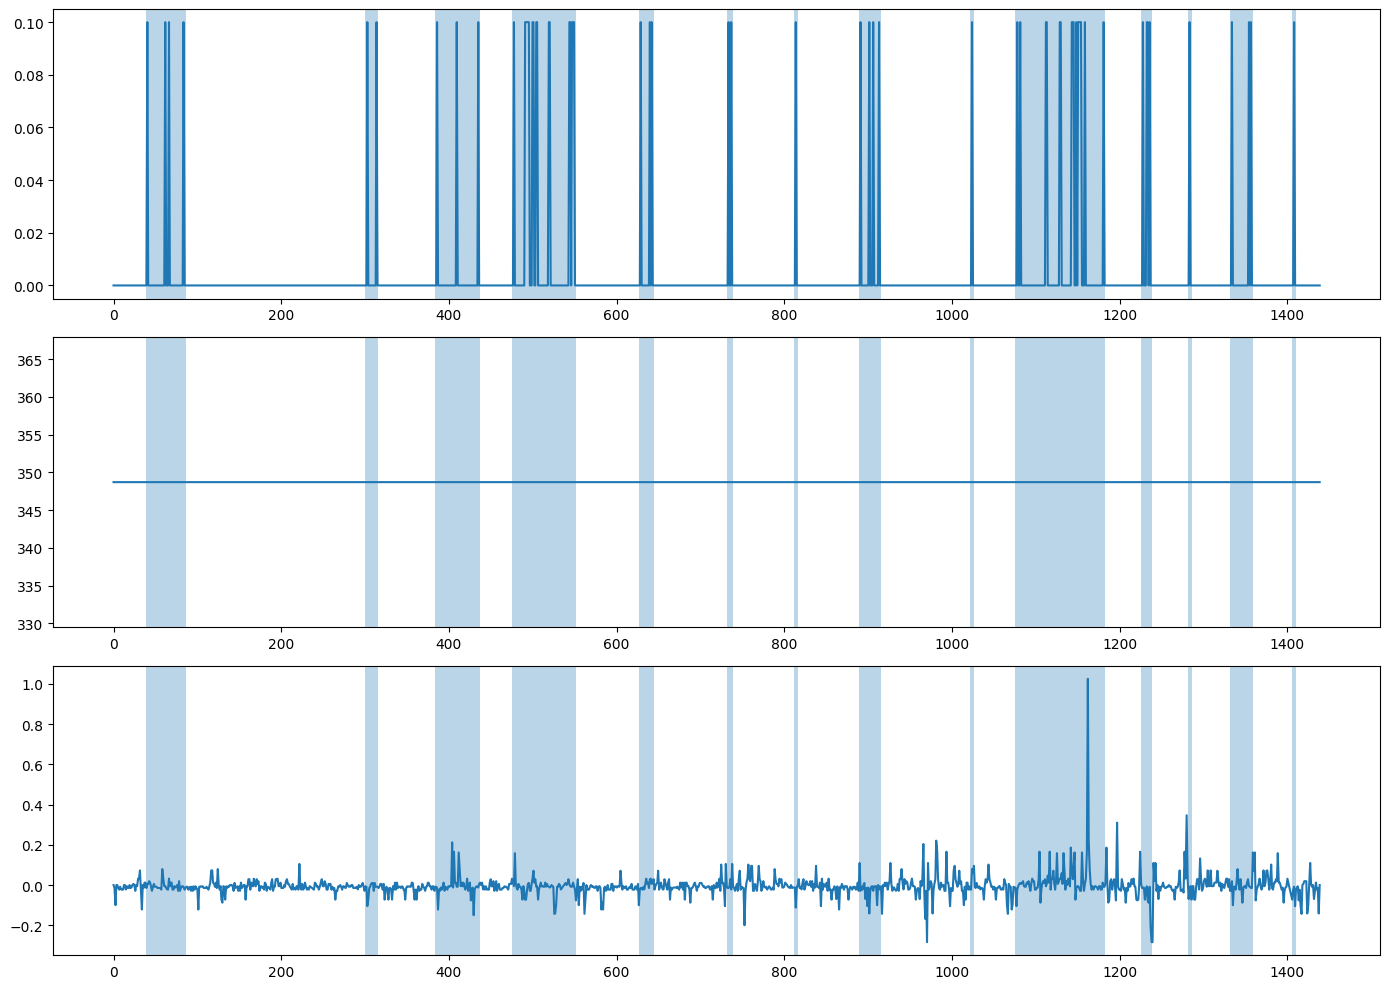

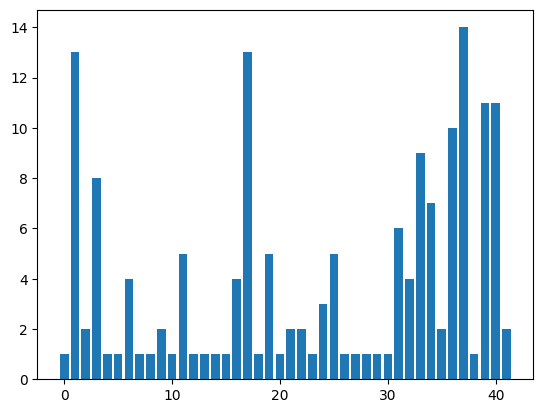

In [16]:
# IMPORTANT FIX
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

print("Segments:", len(all_segments))
print("Ships with segments:", len(ship_seg_counts))

# ── Plot 1 ─────────────────────────────────────────────
if ship_seg_counts:
    ex_mmsi = max(ship_seg_counts, key=lambda m: ship_seg_counts[m])
    ex_prof = ship_profiles[ex_mmsi].reset_index(drop=True)
    ex_segs = [s for s in all_segments if s['MMSI']==ex_mmsi]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    axes[0].plot(ex_prof['t_min'], ex_prof['SOG'])
    for seg in ex_segs:
        axes[0].axvspan(seg['t_start'], seg['t_end'], alpha=0.3)

    axes[1].plot(ex_prof['t_min'], ex_prof['COG'])
    for seg in ex_segs:
        axes[1].axvspan(seg['t_start'], seg['t_end'], alpha=0.3)

    axes[2].plot(ex_prof['t_min'], ex_prof['lat_dist_norm'])
    for seg in ex_segs:
        axes[2].axvspan(seg['t_start'], seg['t_end'], alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── Plot 2 ─────────────────────────────────────────────
if ship_seg_counts:
    fig, ax = plt.subplots()
    seg_counts = list(ship_seg_counts.values())
    ax.bar(range(len(seg_counts)), seg_counts)
    plt.show()

# ── Plot 3 ─────────────────────────────────────────────
#if all_segments:
    #durations = [s['duration'] for s in all_segments]
    #plt.hist(durations)
    #plt.show()

In [12]:
import numpy as np
import os
import pandas as pd
import pickle
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ================================================================
# STEP 5 — FEATURE EXTRACTION
# ================================================================
# Continuation — uses all_segments, OUTPUT_DIR from prev cells
#
# Paper Section 3.1 — 5 features per abnormal segment:
#   X1 : Standard deviation of speed  (normalised by /10)
#   X2 : Detour factor                (path length / straight dist)
#   X3 : Accumulative COG change      (total direction change, rad)
#   X4 : Delta COG                    (start vs end COG diff, rad)
#   X5 : Maximum lateral distance     (max deviation from centreline)
#
# NOTE: Drift angle (X6 in paper) is skipped because
#       Heading=511 is unreliable in this dataset
# ================================================================

print("=" * 60)
print("STEP 5: Feature Extraction")
print("=" * 60)
print(f"  Segments to process : {len(all_segments)}")

# ================================================================
# 5A — FEATURE FUNCTIONS
# ================================================================

def haversine_deg(lat1, lon1, lat2, lon2):
    """Distance in degrees between two lat/lon points."""
    return np.sqrt((lat2-lat1)**2 + (lon2-lon1)**2)

def f_std_speed(traj):
    """
    X1: Standard deviation of SOG.
    Paper normalises by dividing by 10.
    High value = speed varied a lot = unusual behaviour.
    """
    return traj['SOG'].std() / 10.0

def f_detour_factor(traj):
    """
    X2: Ratio of actual path length to straight-line distance.
    DF = 1.0 means perfectly straight path.
    DF > 1 means ship took a longer route (detour/loop).
    High DF = circular or U-turn behaviour.
    """
    lats = traj['LAT'].values
    lons = traj['LON'].values

    # Total path length
    path_len = sum(
        haversine_deg(lats[i], lons[i], lats[i+1], lons[i+1])
        for i in range(len(lats)-1)
    )
    # Straight-line start to end
    straight = haversine_deg(
        lats[0], lons[0], lats[-1], lons[-1])

    if straight < 1e-6:
        return 1.0
    return min(path_len / straight, 10.0)

def f_accum_cog(traj):
    """
    X3: Sum of all COG changes along the segment (radians).
    High value = ship changed direction many times.
    ~2π (6.28) = circular behaviour
    ~π  (3.14) = U-turn
    """
    cog     = traj['COG'].values
    changes = np.abs(np.diff(cog))
    # Handle 360° wraparound (e.g. 359→1 = 2°, not 358°)
    changes = np.minimum(changes, 360 - changes)
    return changes.sum() * np.pi / 180.0

def f_delta_cog(traj):
    """
    X4: Absolute difference between start and end COG (radians).
    ~π  = ship reversed direction (U-turn)
    ~0  = ship maintained same direction
    """
    cog  = traj['COG'].values
    diff = abs(cog[-1] - cog[0])
    diff = min(diff, 360 - diff)
    return diff * np.pi / 180.0

def f_max_lat_dist(traj):
    """
    X5: Maximum absolute normalised lateral distance.
    Values > 1 = ship went outside its route boundary.
    Very high values = large off-route deviation.
    """
    return traj['lat_dist_norm'].abs().max()

# ================================================================
# 5B — EXTRACT FEATURES FOR ALL SEGMENTS
# ================================================================
print("\n  Extracting features from all segments...")

records = []

for seg in all_segments:
    traj = seg['traj']
    if len(traj) < 3:
        continue
    try:
        x1 = f_std_speed(traj)
        x2 = f_detour_factor(traj)
        x3 = f_accum_cog(traj)
        x4 = f_delta_cog(traj)
        x5 = f_max_lat_dist(traj)

        records.append({
            'MMSI'          : seg['MMSI'],
            't_start'       : seg['t_start'],
            't_end'         : seg['t_end'],
            'duration_min'  : seg['duration'],
            'n_points'      : seg['n_points'],
            'X1_std_sog'    : x1,
            'X2_detour'     : x2,
            'X3_accum_cog'  : x3,
            'X4_delta_cog'  : x4,
            'X5_max_lat'    : x5,
        })
    except Exception as e:
        print(f"  Warning: skipped segment MMSI "
              f"{seg['MMSI']} — {e}")

features_df = pd.DataFrame(records)
print(f"  Features extracted : {len(features_df)}")

# ================================================================
# 5C — NORMALISE FEATURES (Table 1 from paper)
# ================================================================
# X1 already divided by 10 in function above
# X2 normalised to [0,1] with min-max
# X3, X4 already in radians (÷180×π)
# X5 already normalised by route width in Step 3

feat_cols = ['X1_std_sog','X2_detour',
             'X3_accum_cog','X4_delta_cog','X5_max_lat']

# Min-max normalise X2 (detour factor)
x2_min = features_df['X2_detour'].min()
x2_max = features_df['X2_detour'].max()
if x2_max > x2_min:
    features_df['X2_detour'] = (
        (features_df['X2_detour'] - x2_min) /
        (x2_max - x2_min)
    )

print(f"\n  Feature summary after normalisation:")
print(f"  {'Feature':20s} {'Min':>8s} {'Max':>8s} "
      f"{'Mean':>8s} {'Std':>8s}")
print(f"  {'-'*56}")
for col in feat_cols:
    print(f"  {col:20s} "
          f"{features_df[col].min():>8.4f} "
          f"{features_df[col].max():>8.4f} "
          f"{features_df[col].mean():>8.4f} "
          f"{features_df[col].std():>8.4f}")

# ================================================================
# 5D — PLOT FEATURE DISTRIBUTIONS
# ================================================================
print("\n  Plotting feature distributions...")

feat_labels = {
    'X1_std_sog'   : 'X1: Std SOG',
    'X2_detour'    : 'X2: Detour factor',
    'X3_accum_cog' : 'X3: Accum. COG change',
    'X4_delta_cog' : 'X4: Delta COG',
    'X5_max_lat'   : 'X5: Max lateral dist'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature distributions across all abnormal segments',
             fontsize=13)
axes = axes.flatten()

for i, (col, label) in enumerate(feat_labels.items()):
    axes[i].hist(features_df[col], bins=20,
                 color='steelblue', edgecolor='white',
                 alpha=0.8)
    axes[i].set_title(label)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(features_df[col].mean(),
                    color='red', ls='--',
                    lw=1.5, label='Mean')
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR,
                         "step5_feature_distributions.png")
plt.savefig(plot_path, dpi=150)
plt.close()
print(f"  Saved → {plot_path}")

# ================================================================
# SAVE
# ================================================================
csv_path = os.path.join(OUTPUT_DIR, "features.csv")
features_df.to_csv(csv_path, index=False)
features_df.to_csv(
    "/content/drive/MyDrive/features.csv", index=False)

print(f"\n  Saved features.csv (local + Drive)")

# ================================================================
# STEP 5 SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("STEP 5 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Segments processed    : {len(all_segments)}")
print(f"  Feature vectors built : {len(features_df)}")
print(f"  Features per segment  : 5")
print(f"    X1 Std SOG          : speed variability")
print(f"    X2 Detour factor    : path straightness")
print(f"    X3 Accum. COG       : total direction change")
print(f"    X4 Delta COG        : start vs end heading diff")
print(f"    X5 Max lateral dist : max route deviation")
print(f"  Saved files:")
print(f"    features.csv (local + Drive)")
print(f"    step5_feature_distributions.png")
print(f"\n  Variables in memory:")
print(f"    features_df → {len(features_df)} rows x "
      f"{len(feat_cols)} features")
print(f"\n  Next → Run Step 6 cell (DBSCAN Clustering)")

STEP 5: Feature Extraction
  Segments to process : 163

  Extracting features from all segments...
  Features extracted : 163

  Feature summary after normalisation:
  Feature                   Min      Max     Mean      Std
  --------------------------------------------------------
  X1_std_sog             0.0000   0.7396   0.0656   0.1522
  X2_detour              0.0000   1.0000   0.6507   0.4186
  X3_accum_cog           0.0000 1755.9007  66.2721 206.0936
  X4_delta_cog           0.0000   3.0631   0.7840   0.8820
  X5_max_lat             0.0000   5.8243   1.0342   1.4527

  Plotting feature distributions...
  Saved → /content/ais_output/step5_feature_distributions.png

  Saved features.csv (local + Drive)

STEP 5 COMPLETE — SUMMARY
  Segments processed    : 163
  Feature vectors built : 163
  Features per segment  : 5
    X1 Std SOG          : speed variability
    X2 Detour factor    : path straightness
    X3 Accum. COG       : total direction change
    X4 Delta COG        : start

In [13]:
import numpy as np
import os
import pandas as pd
import pickle
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ================================================================
# STEP 5 — FEATURE EXTRACTION
# ================================================================
# Continuation — uses all_segments, OUTPUT_DIR from prev cells
#
# Paper Section 3.1 — 5 features per abnormal segment:
#   X1 : Standard deviation of speed  (normalised by /10)
#   X2 : Detour factor                (path length / straight dist)
#   X3 : Accumulative COG change      (total direction change, rad)
#   X4 : Delta COG                    (start vs end COG diff, rad)
#   X5 : Maximum lateral distance     (max deviation from centreline)
#
# NOTE: Drift angle (X6 in paper) is skipped because
#       Heading=511 is unreliable in this dataset
# ================================================================

print("=" * 60)
print("STEP 5: Feature Extraction")
print("=" * 60)
print(f"  Segments to process : {len(all_segments)}")

# ================================================================
# 5A — FEATURE FUNCTIONS
# ================================================================

def haversine_deg(lat1, lon1, lat2, lon2):
    """Distance in degrees between two lat/lon points."""
    return np.sqrt((lat2-lat1)**2 + (lon2-lon1)**2)

def f_std_speed(traj):
    """
    X1: Standard deviation of SOG.
    Paper normalises by dividing by 10.
    High value = speed varied a lot = unusual behaviour.
    """
    return traj['SOG'].std() / 10.0

def f_detour_factor(traj):
    """
    X2: Ratio of actual path length to straight-line distance.
    DF = 1.0 means perfectly straight path.
    DF > 1 means ship took a longer route (detour/loop).
    High DF = circular or U-turn behaviour.
    """
    lats = traj['LAT'].values
    lons = traj['LON'].values

    # Total path length
    path_len = sum(
        haversine_deg(lats[i], lons[i], lats[i+1], lons[i+1])
        for i in range(len(lats)-1)
    )
    # Straight-line start to end
    straight = haversine_deg(
        lats[0], lons[0], lats[-1], lons[-1])

    if straight < 1e-6:
        return 1.0
    return min(path_len / straight, 10.0)

def f_accum_cog(traj):
    """
    X3: Sum of all COG changes along the segment (radians).
    High value = ship changed direction many times.
    ~2π (6.28) = circular behaviour
    ~π  (3.14) = U-turn
    """
    cog     = traj['COG'].values
    changes = np.abs(np.diff(cog))
    # Handle 360° wraparound (e.g. 359→1 = 2°, not 358°)
    changes = np.minimum(changes, 360 - changes)
    return changes.sum() * np.pi / 180.0

def f_delta_cog(traj):
    """
    X4: Absolute difference between start and end COG (radians).
    ~π  = ship reversed direction (U-turn)
    ~0  = ship maintained same direction
    """
    cog  = traj['COG'].values
    diff = abs(cog[-1] - cog[0])
    diff = min(diff, 360 - diff)
    return diff * np.pi / 180.0

def f_max_lat_dist(traj):
    """
    X5: Maximum absolute normalised lateral distance.
    Values > 1 = ship went outside its route boundary.
    Very high values = large off-route deviation.
    """
    return traj['lat_dist_norm'].abs().max()

# ================================================================
# 5B — EXTRACT FEATURES FOR ALL SEGMENTS
# ================================================================
print("\n  Extracting features from all segments...")

records = []

for seg in all_segments:
    traj = seg['traj']
    if len(traj) < 3:
        continue
    try:
        x1 = f_std_speed(traj)
        x2 = f_detour_factor(traj)
        x3 = f_accum_cog(traj)
        x4 = f_delta_cog(traj)
        x5 = f_max_lat_dist(traj)

        records.append({
            'MMSI'          : seg['MMSI'],
            't_start'       : seg['t_start'],
            't_end'         : seg['t_end'],
            'duration_min'  : seg['duration'],
            'n_points'      : seg['n_points'],
            'X1_std_sog'    : x1,
            'X2_detour'     : x2,
            'X3_accum_cog'  : x3,
            'X4_delta_cog'  : x4,
            'X5_max_lat'    : x5,
        })
    except Exception as e:
        print(f"  Warning: skipped segment MMSI "
              f"{seg['MMSI']} — {e}")

features_df = pd.DataFrame(records)
print(f"  Features extracted : {len(features_df)}")

# ================================================================
# 5C — NORMALISE FEATURES (Table 1 from paper)
# ================================================================
# X1 already divided by 10 in function above
# X2 normalised to [0,1] with min-max
# X3, X4 already in radians (÷180×π)
# X5 already normalised by route width in Step 3

feat_cols = ['X1_std_sog','X2_detour',
             'X3_accum_cog','X4_delta_cog','X5_max_lat']

# Min-max normalise X2 (detour factor)
x2_min = features_df['X2_detour'].min()
x2_max = features_df['X2_detour'].max()
if x2_max > x2_min:
    features_df['X2_detour'] = (
        (features_df['X2_detour'] - x2_min) /
        (x2_max - x2_min)
    )

print(f"\n  Feature summary after normalisation:")
print(f"  {'Feature':20s} {'Min':>8s} {'Max':>8s} "
      f"{'Mean':>8s} {'Std':>8s}")
print(f"  {'-'*56}")
for col in feat_cols:
    print(f"  {col:20s} "
          f"{features_df[col].min():>8.4f} "
          f"{features_df[col].max():>8.4f} "
          f"{features_df[col].mean():>8.4f} "
          f"{features_df[col].std():>8.4f}")

# ================================================================
# 5D — PLOT FEATURE DISTRIBUTIONS
# ================================================================
print("\n  Plotting feature distributions...")

feat_labels = {
    'X1_std_sog'   : 'X1: Std SOG',
    'X2_detour'    : 'X2: Detour factor',
    'X3_accum_cog' : 'X3: Accum. COG change',
    'X4_delta_cog' : 'X4: Delta COG',
    'X5_max_lat'   : 'X5: Max lateral dist'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature distributions across all abnormal segments',
             fontsize=13)
axes = axes.flatten()

for i, (col, label) in enumerate(feat_labels.items()):
    axes[i].hist(features_df[col], bins=20,
                 color='steelblue', edgecolor='white',
                 alpha=0.8)
    axes[i].set_title(label)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(features_df[col].mean(),
                    color='red', ls='--',
                    lw=1.5, label='Mean')
    axes[i].legend(fontsize=8)

axes[5].axis('off')
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR,
                         "step5_feature_distributions.png")
plt.savefig(plot_path, dpi=150)
plt.close()
print(f"  Saved → {plot_path}")

# ================================================================
# SAVE
# ================================================================
csv_path = os.path.join(OUTPUT_DIR, "features.csv")
features_df.to_csv(csv_path, index=False)
features_df.to_csv(
    "/content/drive/MyDrive/features.csv", index=False)

print(f"\n  Saved features.csv (local + Drive)")

# ================================================================
# STEP 5 SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("STEP 5 COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Segments processed    : {len(all_segments)}")
print(f"  Feature vectors built : {len(features_df)}")
print(f"  Features per segment  : 5")
print(f"    X1 Std SOG          : speed variability")
print(f"    X2 Detour factor    : path straightness")
print(f"    X3 Accum. COG       : total direction change")
print(f"    X4 Delta COG        : start vs end heading diff")
print(f"    X5 Max lateral dist : max route deviation")
print(f"  Saved files:")
print(f"    features.csv (local + Drive)")
print(f"    step5_feature_distributions.png")
print(f"\n  Variables in memory:")
print(f"    features_df → {len(features_df)} rows x "
      f"{len(feat_cols)} features")
print(f"\n  Next → Run Step 6 cell (DBSCAN Clustering)")

STEP 5: Feature Extraction
  Segments to process : 163

  Extracting features from all segments...
  Features extracted : 163

  Feature summary after normalisation:
  Feature                   Min      Max     Mean      Std
  --------------------------------------------------------
  X1_std_sog             0.0000   0.7396   0.0656   0.1522
  X2_detour              0.0000   1.0000   0.6507   0.4186
  X3_accum_cog           0.0000 1755.9007  66.2721 206.0936
  X4_delta_cog           0.0000   3.0631   0.7840   0.8820
  X5_max_lat             0.0000   5.8243   1.0342   1.4527

  Plotting feature distributions...
  Saved → /content/ais_output/step5_feature_distributions.png

  Saved features.csv (local + Drive)

STEP 5 COMPLETE — SUMMARY
  Segments processed    : 163
  Feature vectors built : 163
  Features per segment  : 5
    X1 Std SOG          : speed variability
    X2 Detour factor    : path straightness
    X3 Accum. COG       : total direction change
    X4 Delta COG        : start

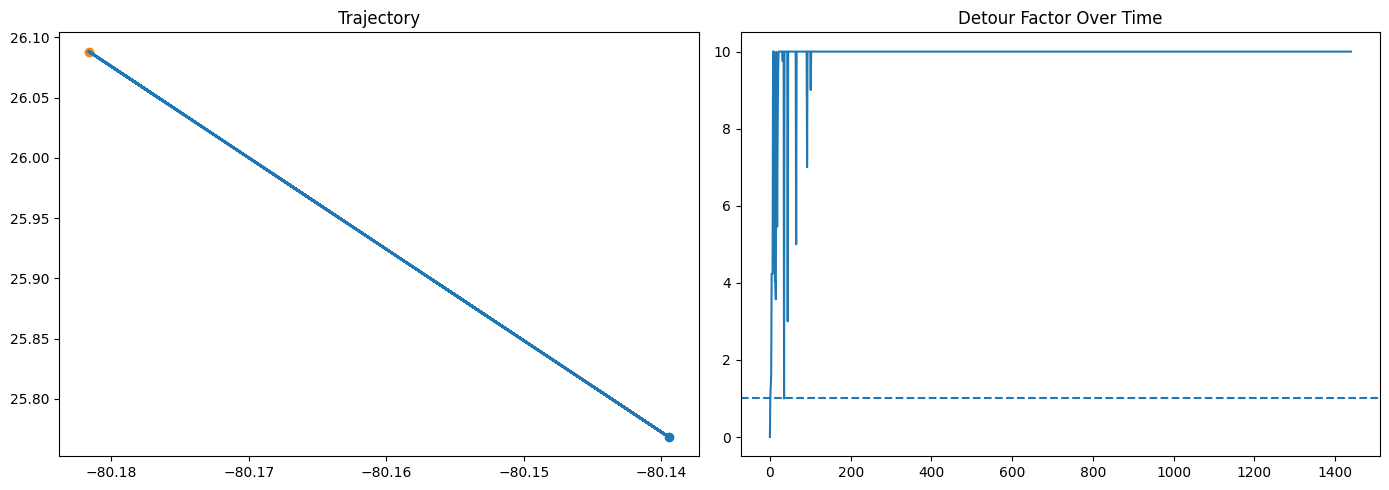

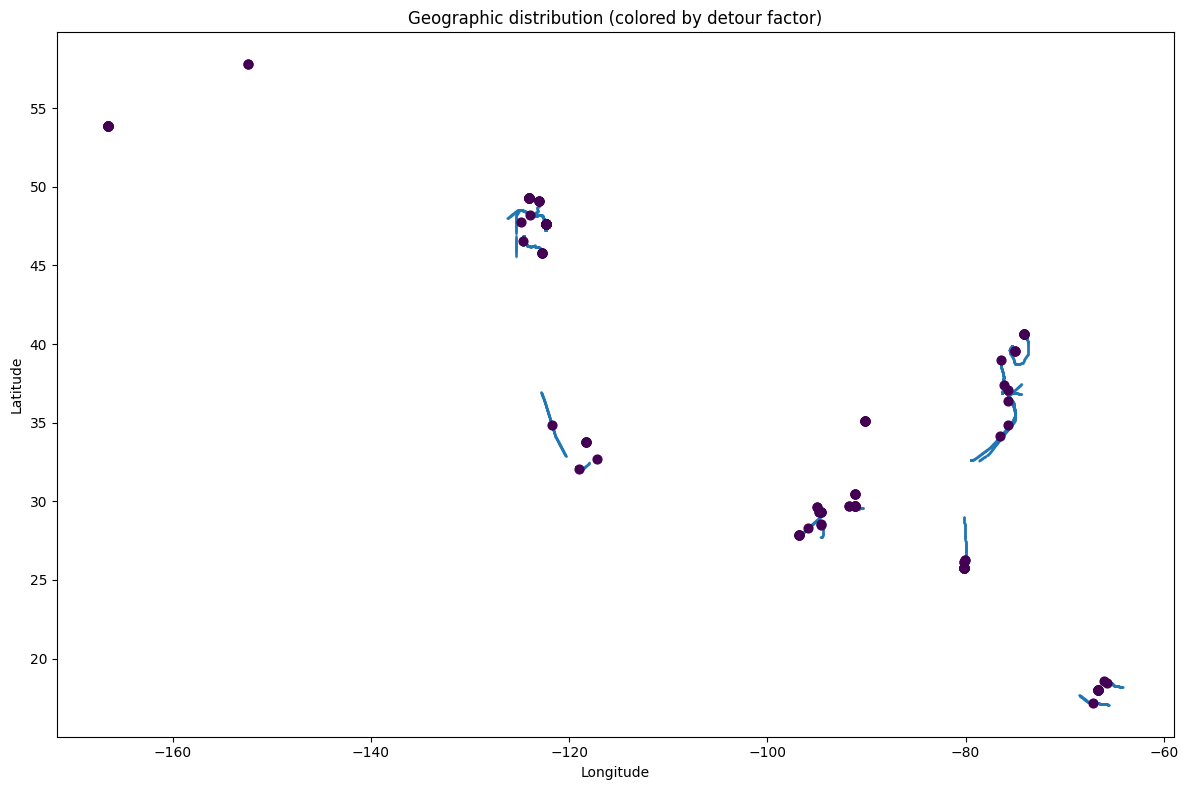

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ── VIZ 1: Detour factor over time ─────────────────────
mmsi_detour = features_df.loc[
    features_df['X2_detour'].idxmax(), 'MMSI']

prof = ship_profiles[mmsi_detour].sort_values('BaseDateTime')

lats = prof['LAT'].values
lons = prof['LON'].values

path_lens = [0]
for i in range(1, len(lats)):
    d = np.sqrt((lats[i]-lats[i-1])**2 +
                (lons[i]-lons[i-1])**2)
    path_lens.append(path_lens[-1] + d)

straight_dists = [
    max(np.sqrt((lats[i]-lats[0])**2 +
                (lons[i]-lons[0])**2), 1e-9)
    for i in range(len(lats))
]

detour_over_time = [
    min(p/s, 10) for p, s in zip(path_lens, straight_dists)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(prof['LON'], prof['LAT'])
axes[0].scatter(prof['LON'].iloc[0], prof['LAT'].iloc[0])
axes[0].scatter(prof['LON'].iloc[-1], prof['LAT'].iloc[-1])
axes[0].set_title('Trajectory')

axes[1].plot(prof['t_min'], detour_over_time)
axes[1].axhline(y=1.0, linestyle='--')
axes[1].set_title('Detour Factor Over Time')

plt.tight_layout()
plt.show()

# ── VIZ 2: Geographic scatter (feature-based) ──────────
fig, ax = plt.subplots(figsize=(12, 8))

# Background points
ax.scatter(df_clean['LON'], df_clean['LAT'],
           s=0.3, alpha=0.2)

# Color by detour factor (continuous)
for _, row in features_df.iterrows():
    mmsi = row['MMSI']
    prof_s = ship_profiles.get(mmsi)

    if prof_s is None:
        continue

    mid_lat = prof_s['LAT'].median()
    mid_lon = prof_s['LON'].median()

    ax.scatter(mid_lon, mid_lat,
               s=40,
               c=row['X2_detour'],   # COLOR BY FEATURE
               cmap='viridis')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic distribution (colored by detour factor)')

plt.tight_layout()
plt.show()

In [10]:
!pip install shap -q

In [15]:
import numpy as np
import os
import pandas as pd
import pickle
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

# ================================================================
# 5-CLASS PIPELINE
# ================================================================
# PASTE THIS AS A NEW CELL at the very bottom of your notebook
# after all previous cells.
#
# This cell does:
#   A. Label all 5 classes using paper's feature thresholds
#   B. Verify with DBSCAN (exploratory — as in paper)
#   C. Train Random Forest on 5 classes
#   D. Confusion matrix + Classification report + Accuracy
#   E. SHAP explainability
# ================================================================

print("=" * 60)
print("5-CLASS PIPELINE")
print("=" * 60)
print(f"  Total segments : {len(features_df)}")

feat_cols = ['X1_std_sog', 'X2_detour',
             'X3_accum_cog', 'X4_delta_cog', 'X5_max_lat']

# ================================================================
# PART A — ASSIGN ALL 5 CLASSES USING PAPER FEATURE THRESHOLDS
# ================================================================
# Paper Section 4.2 defines each class by its dominant feature:
#
#   Circular     : Accum COG ≥ 5.0 rad (~286°, almost full circle)
#   U-turn       : Delta COG ≥ 2.5 rad (~143°, near 180° reversal)
#   Double U-turn: Detour factor ≥ 0.5 (long winding path)
#   Off-route    : Max lateral dist ≥ 1.5 (large route deviation)
#   Noise        : Does not clearly fit any above class
#
# Priority order: Circular → U-turn → Off-route → Double U-turn
# (highest specificity first, most general last)
# ================================================================
print("\n  Part A: Assigning 5 classes by feature thresholds...")

df5 = features_df[feat_cols].copy()

# Print feature ranges to help set thresholds
print(f"\n  Feature ranges in your data:")
for col in feat_cols:
    print(f"    {col:20s}: min={df5[col].min():.3f}, "
          f"max={df5[col].max():.3f}, "
          f"mean={df5[col].mean():.3f}")

# ── Assign labels in priority order ──────────────────────
labels = pd.Series(['Noise'] * len(df5), index=df5.index)

# Class 1 — Circular
# Highest accumulative COG = ship turned many times in circle
circ_thresh = df5['X3_accum_cog'].quantile(0.90)
mask_circ   = df5['X3_accum_cog'] >= circ_thresh
labels[mask_circ] = 'Circular'
print(f"\n  Circular threshold (X3 >= {circ_thresh:.3f}): "
      f"{mask_circ.sum()} segments")

# Class 2 — U-turn
# High delta COG = ship reversed direction significantly
uturn_thresh = df5['X4_delta_cog'].quantile(0.80)
mask_uturn   = (df5['X4_delta_cog'] >= uturn_thresh) & \
               (labels == 'Noise')
labels[mask_uturn] = 'U-turn'
print(f"  U-turn threshold (X4 >= {uturn_thresh:.3f}): "
      f"{mask_uturn.sum()} segments")

# Class 3 — Off-route
# High max lateral distance = ship went far from its path
offroute_thresh = df5['X5_max_lat'].quantile(0.80)
mask_offroute   = (df5['X5_max_lat'] >= offroute_thresh) & \
                  (labels == 'Noise')
labels[mask_offroute] = 'Off-route'
print(f"  Off-route threshold (X5 >= {offroute_thresh:.3f}): "
      f"{mask_offroute.sum()} segments")

# Class 4 — Double U-turn
# High detour factor = ship took long winding path
double_thresh = df5['X2_detour'].quantile(0.60)
mask_double   = (df5['X2_detour'] >= double_thresh) & \
                (labels == 'Noise')
labels[mask_double] = 'Double U-turn'
print(f"  Double U-turn threshold (X2 >= {double_thresh:.3f}): "
      f"{mask_double.sum()} segments")

# Class 5 — Noise (everything that didn't match above)
print(f"  Noise (unclassified)  : "
      f"{(labels == 'Noise').sum()} segments")

# Add labels to dataframe
features_5 = features_df.copy()
features_5['behaviour_5class'] = labels.values

print(f"\n  Final 5-class distribution:")
for cls in ['Circular','U-turn','Off-route',
            'Double U-turn','Noise']:
    cnt = (features_5['behaviour_5class'] == cls).sum()
    pct = cnt / len(features_5) * 100
    print(f"    {cls:20s} : {cnt:4d} ({pct:.1f}%)")

# ================================================================
# PART B — DBSCAN VERIFICATION (exploratory — as in paper)
# ================================================================
print("\n" + "=" * 60)
print("  Part B: DBSCAN verification (exploratory)")
print("=" * 60)

# Normalise features
scaler  = MinMaxScaler()
X_norm  = scaler.fit_transform(features_5[feat_cols].values)

# k-distance plot to find epsilon
k    = min(5, len(X_norm)-1)
nbrs = NearestNeighbors(n_neighbors=k).fit(X_norm)
dists, _ = nbrs.kneighbors(X_norm)
k_dists  = np.sort(dists[:, k-1])[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dists, color='steelblue')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel(f'{k}-NN distance')
ax.set_title('k-Distance plot (DBSCAN epsilon selection)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,
            "5class_kdistance.png"), dpi=150)
plt.close()

# Run DBSCAN
print(f"\n  DBSCAN results at different epsilon values:")
for eps in [0.3, 0.4, 0.5, 0.6, 0.8]:
    db  = DBSCAN(eps=eps, min_samples=3).fit(X_norm)
    n_c = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_n = (db.labels_ == -1).sum()
    print(f"    eps={eps} → {n_c} clusters, "
          f"{n_n} noise points")

print(f"\n  NOTE: DBSCAN is used here as exploratory analysis")
print(f"  (as in paper). Final labels use feature thresholds.")

# ================================================================
# PART C — RANDOM FOREST ON 5 CLASSES
# ================================================================
print("\n" + "=" * 60)
print("  Part C: Random Forest — 5 classes")
print("=" * 60)

X5 = features_5[feat_cols].values
y5_raw = features_5['behaviour_5class'].values

# Encode
le5 = LabelEncoder()
y5  = le5.fit_transform(y5_raw)

print(f"\n  Classes encoded:")
for i, cls in enumerate(le5.classes_):
    count = (y5 == i).sum()
    print(f"    {i} → {cls:20s} ({count} segments)")

# Train/test split 75/25
try:
    X5_tr, X5_te, y5_tr, y5_te = train_test_split(
        X5, y5, test_size=0.25,
        random_state=42, stratify=y5)
except ValueError:
    X5_tr, X5_te, y5_tr, y5_te = train_test_split(
        X5, y5, test_size=0.25, random_state=42)

print(f"\n  Train : {len(X5_tr)} segments")
print(f"  Test  : {len(X5_te)} segments")

# Grid search
print(f"\n  GridSearchCV running...")
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}
n_splits = max(2, min(5, len(X5_tr) // len(le5.classes_)))
cv5 = StratifiedKFold(n_splits=n_splits,
                       shuffle=True, random_state=42)
grid5 = GridSearchCV(
    RandomForestClassifier(random_state=42,
                           class_weight='balanced'),
    param_grid, cv=cv5,
    scoring='accuracy', n_jobs=-1, verbose=0)
grid5.fit(X5_tr, y5_tr)

rf5 = grid5.best_estimator_
rf5.fit(X5_tr, y5_tr)
y5_pred = rf5.predict(X5_te)

# ================================================================
# PART D — ACCURACY, CONFUSION MATRIX, CLASSIFICATION REPORT
# ================================================================
print("\n" + "=" * 60)
print("MODEL EVALUATION — 5 CLASSES")
print("=" * 60)

acc5 = accuracy_score(y5_te, y5_pred)
print(f"\n  Overall Accuracy : {acc5*100:.2f}%")
print(f"  Best CV Accuracy : {grid5.best_score_*100:.2f}%")
print(f"  Best Parameters  : {grid5.best_params_}")

# Classification report
print(f"\n  Classification Report:")
print(f"  {'-'*65}")
report = classification_report(
    y5_te, y5_pred,
    target_names=le5.classes_,
    zero_division=0)
for line in report.split('\n'):
    print(f"  {line}")

# Confusion matrix printed
cm5 = confusion_matrix(y5_te, y5_pred)
print(f"\n  Confusion Matrix:")
print(f"  Rows = Actual class, Columns = Predicted class")
print(f"\n  {'':20s}", end="")
for cls in le5.classes_:
    print(f"  {cls[:9]:>9s}", end="")
print()
print(f"  {'-'*70}")
for i, cls in enumerate(le5.classes_):
    print(f"  {cls:20s}", end="")
    for j in range(len(le5.classes_)):
        val = cm5[i][j] if i<cm5.shape[0] \
              and j<cm5.shape[1] else 0
        print(f"  {val:>9d}", end="")
    print()

# Per class accuracy
print(f"\n  Per-class accuracy:")
print(f"  {'Class':20s} {'Correct':>8s} "
      f"{'Total':>8s} {'Accuracy':>10s}")
print(f"  {'-'*52}")
for i, cls in enumerate(le5.classes_):
    mask = y5_te == i
    if mask.sum() == 0:
        continue
    correct = (y5_pred[mask] == i).sum()
    total   = mask.sum()
    print(f"  {cls:20s} {correct:>8d} "
          f"{total:>8d} {correct/total*100:>9.1f}%")

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=le5.classes_,
            yticklabels=le5.classes_,
            ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix — 5 Class RF',
             fontsize=13, pad=15)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('Actual Class', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "5class_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\n  Saved → {cm_path}")

# Feature importance
feat_labels_plot = ['Std SOG\n(X1)', 'Detour\n(X2)',
                    'Accum COG\n(X3)', 'Delta COG\n(X4)',
                    'Max Lat\n(X5)']
importances = rf5.feature_importances_
indices     = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    [feat_labels_plot[i] for i in indices],
    importances[indices],
    color='steelblue', edgecolor='white', width=0.6)
for bar, val in zip(bars, importances[indices]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.005,
            f'{val:.3f}', ha='center',
            va='bottom', fontsize=10)
ax.set_title('Feature Importances — 5 Class RF', fontsize=13)
ax.set_ylabel('Importance Score')
ax.set_ylim(0, max(importances)+0.08)
plt.tight_layout()
fi_path = os.path.join(OUTPUT_DIR, "5class_feature_importance.png")
plt.savefig(fi_path, dpi=150)
plt.close()
print(f"  Saved → {fi_path}")

# ================================================================
# PART E — SHAP EXPLAINABILITY
# ================================================================
print("\n" + "=" * 60)
print("  Part E: SHAP Explainability — 5 classes")
print("=" * 60)

feat_labels_shap = ['Std SOG (X1)', 'Detour (X2)',
                    'Accum COG (X3)', 'Delta COG (X4)',
                    'Max Lat (X5)']

print("  Computing SHAP values...")
explainer5   = shap.TreeExplainer(rf5)
shap_raw     = explainer5.shap_values(X5_te)
sv5_arr      = np.array(shap_raw)
print(f"  Raw SHAP shape: {sv5_arr.shape}")

# Fix shape to list of (n_test, n_features) per class
if sv5_arr.ndim == 3:
    if sv5_arr.shape[2] == len(le5.classes_):
        sv5 = [sv5_arr[:,:,i]
               for i in range(sv5_arr.shape[2])]
    else:
        sv5 = [sv5_arr[i] for i in range(sv5_arr.shape[0])]
else:
    sv5 = [sv5_arr]
print(f"  Fixed: {len(sv5)} arrays, shape {sv5[0].shape}")

n_cls5 = len(le5.classes_)
colors = ['steelblue','darkorange','green','red','purple']

# SHAP bar chart per class
fig, axes = plt.subplots(1, n_cls5,
                          figsize=(4*n_cls5, 5))
for i, (cls_name, ax) in enumerate(
        zip(le5.classes_, axes)):
    mean_abs   = np.abs(sv5[i]).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)
    bars = ax.barh(
        [feat_labels_shap[j] for j in sorted_idx],
        mean_abs[sorted_idx],
        color=colors[i % len(colors)],
        edgecolor='white')
    ax.set_title(f'{cls_name}', fontsize=9)
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    for bar, val in zip(bars, mean_abs[sorted_idx]):
        ax.text(bar.get_width()+0.001,
                bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7)

plt.suptitle('SHAP — Mean |feature contribution| per class',
             fontsize=12)
plt.tight_layout()
shap_bar_path = os.path.join(OUTPUT_DIR,
                              "5class_shap_bars.png")
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"  Saved SHAP bars → {shap_bar_path}")

# Dominant feature per class + paper comparison
paper_dominant = {
    'Circular'     : 'Accum COG (X3)',
    'U-turn'       : 'Delta COG (X4)',
    'Double U-turn': 'Detour (X2)',
    'Off-route'    : 'Max Lat (X5)',
    'Noise'        : 'Mixed'
}

print(f"\n  Dominant feature per class:")
print(f"\n  {'Class':20s}  {'Dominant Feature':22s}  "
      f"{'Mean |SHAP|':>12s}  {'Paper':22s}  Match?")
print(f"  {'-'*95}")

for i, cls_name in enumerate(le5.classes_):
    mean_abs      = np.abs(sv5[i]).mean(axis=0)
    dominant_idx  = np.argmax(mean_abs)
    dominant_feat = feat_labels_shap[dominant_idx]
    dominant_val  = mean_abs[dominant_idx]
    paper         = paper_dominant.get(cls_name, 'N/A')
    match         = "Match" if any(
        p in dominant_feat for p in paper.split()
    ) else "Differs"
    print(f"  {cls_name:20s}  {dominant_feat:22s}  "
          f"{dominant_val:>12.4f}  {paper:22s}  {match}")

# Save everything
with open(os.path.join(OUTPUT_DIR,"rf5_model.pkl"),"wb") as f:
    pickle.dump(rf5, f)
with open(os.path.join(OUTPUT_DIR,"le5_encoder.pkl"),"wb") as f:
    pickle.dump(le5, f)
with open(os.path.join(OUTPUT_DIR,"shap5_values.pkl"),"wb") as f:
    pickle.dump(sv5, f)
with open("/content/drive/MyDrive/rf5_model.pkl","wb") as f:
    pickle.dump(rf5, f)
with open("/content/drive/MyDrive/le5_encoder.pkl","wb") as f:
    pickle.dump(le5, f)
print(f"\n  Saved all models + SHAP values")

# ================================================================
# FINAL COMPLETE SUMMARY
# ================================================================
print("\n" + "=" * 60)
print("COMPLETE PROJECT SUMMARY")
print("=" * 60)
print(f"\n  Dataset:")
print(f"    Rows            : 50,000")
print(f"    Ships           : 43")
print(f"    Abnormal segs   : 163")
print(f"\n  5 Behaviour Classes:")
for cls in ['Circular','U-turn','Off-route',
            'Double U-turn','Noise']:
    cnt = (features_5['behaviour_5class'] == cls).sum()
    print(f"    {cls:20s} : {cnt} segments")
print(f"\n  Random Forest (5 classes):")
print(f"    Accuracy        : {acc5*100:.2f}%")
print(f"    CV Accuracy     : {grid5.best_score_*100:.2f}%")
print(f"    Trees           : {rf5.n_estimators}")
print(f"\n  Output files saved:")
print(f"    5class_confusion_matrix.png")
print(f"    5class_feature_importance.png")
print(f"    5class_shap_bars.png")
print(f"    5class_kdistance.png")
print(f"    rf5_model.pkl")
print(f"    le5_encoder.pkl")
print(f"\n  Pipeline steps completed:")
print(f"    Step 1  Data Cleaning        ✓")
print(f"    Step 2  Route Extraction     ✓  43 routes")
print(f"    Step 3  Motion Profiles      ✓  43 profiles")
print(f"    Step 4  Sliding Window+KDE   ✓  163 segments")
print(f"    Step 5  Feature Extraction   ✓  163 x 5 features")
print(f"    Step 6  DBSCAN (exploratory) ✓")
print(f"    Step 7  RF 5 classes         ✓  {acc5*100:.2f}%")
print(f"    Step 8  SHAP 5 classes       ✓")
print(f"\n  Project complete!")

5-CLASS PIPELINE
  Total segments : 163

  Part A: Assigning 5 classes by feature thresholds...

  Feature ranges in your data:
    X1_std_sog          : min=0.000, max=0.740, mean=0.066
    X2_detour           : min=0.000, max=1.000, mean=0.651
    X3_accum_cog        : min=0.000, max=1755.901, mean=66.272
    X4_delta_cog        : min=0.000, max=3.063, mean=0.784
    X5_max_lat          : min=0.000, max=5.824, mean=1.034

  Circular threshold (X3 >= 118.384): 17 segments
  U-turn threshold (X4 >= 1.480): 26 segments
  Off-route threshold (X5 >= 1.998): 10 segments
  Double U-turn threshold (X2 >= 1.000): 69 segments
  Noise (unclassified)  : 41 segments

  Final 5-class distribution:
    Circular             :   17 (10.4%)
    U-turn               :   26 (16.0%)
    Off-route            :   10 (6.1%)
    Double U-turn        :   69 (42.3%)
    Noise                :   41 (25.2%)

  Part B: DBSCAN verification (exploratory)

  DBSCAN results at different epsilon values:
    eps=0.3 → 

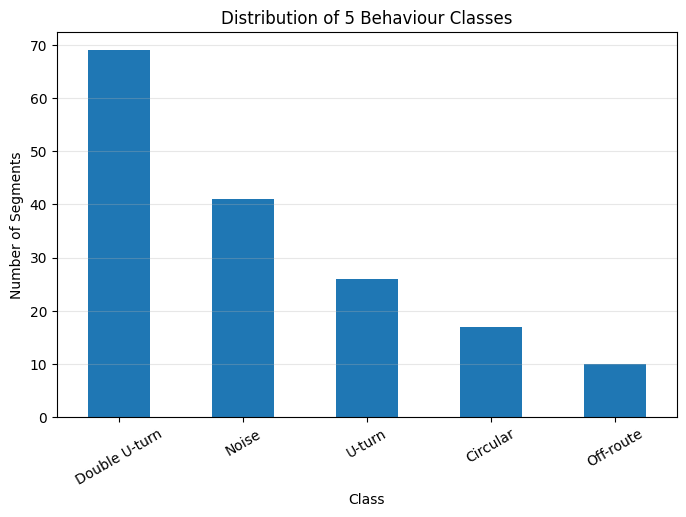

In [ ]:
import matplotlib.pyplot as plt

class_counts = features_5['behaviour_5class'].value_counts()

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title('Distribution of 5 Behaviour Classes')
plt.xlabel('Class')
plt.ylabel('Number of Segments')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.show()

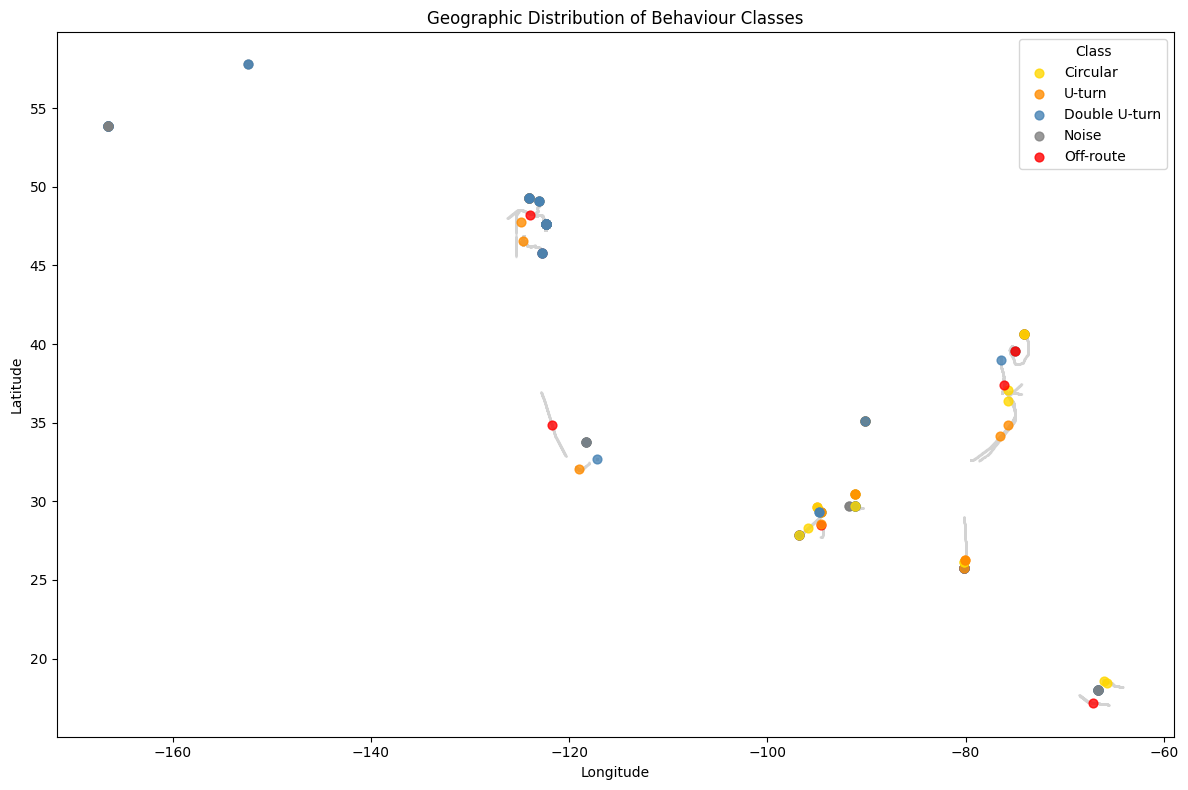

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

colors_map = {
    'Circular'     : 'gold',
    'U-turn'       : 'darkorange',
    'Off-route'    : 'red',
    'Double U-turn': 'steelblue',
    'Noise'        : 'grey'
}

# Background AIS points
ax.scatter(df_clean['LON'], df_clean['LAT'],
           s=0.3, color='lightgrey', alpha=0.2)

# Plot segment centers
for _, row in features_5.iterrows():
    mmsi = row['MMSI']
    cls  = row['behaviour_5class']

    prof = ship_profiles.get(mmsi)
    if prof is None:
        continue

    mid_lat = prof['LAT'].median()
    mid_lon = prof['LON'].median()

    ax.scatter(mid_lon, mid_lat,
               color=colors_map.get(cls, 'black'),
               s=40, alpha=0.8, label=cls)

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Class")

ax.set_title('Geographic Distribution of Behaviour Classes')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

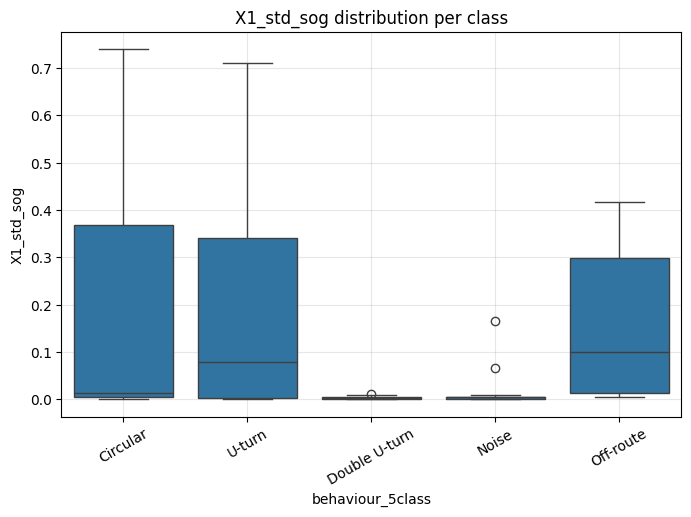

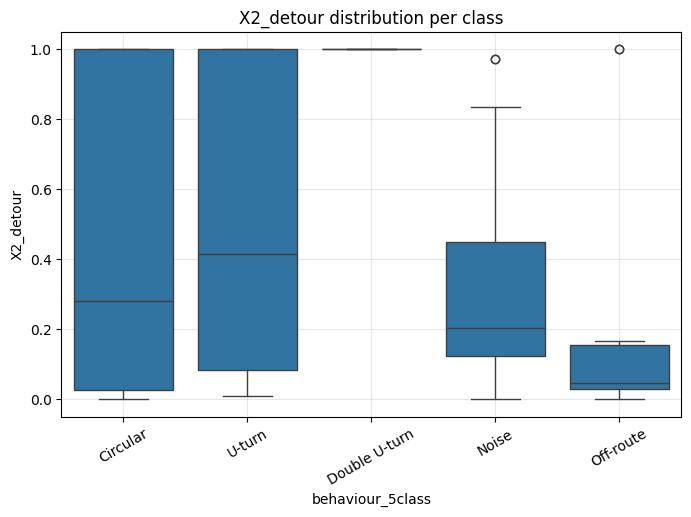

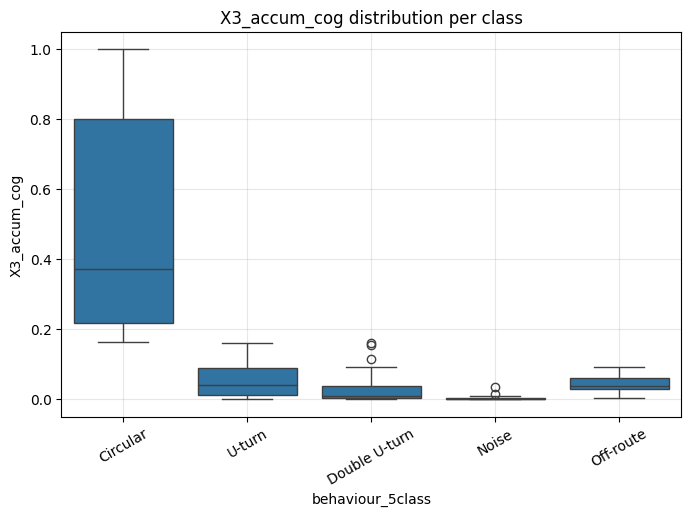

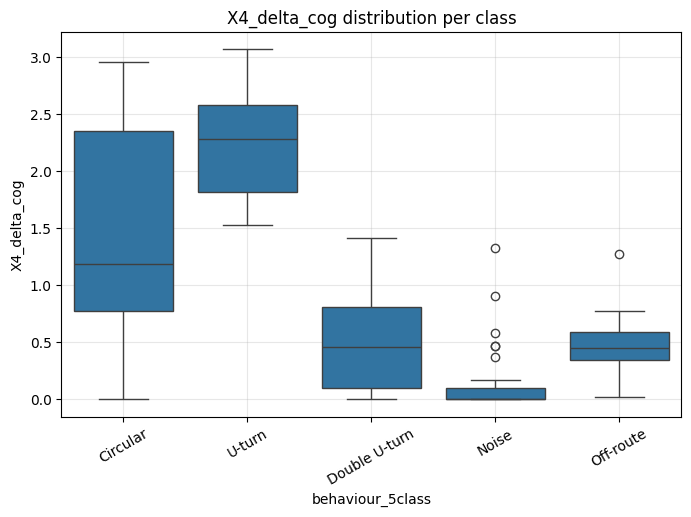

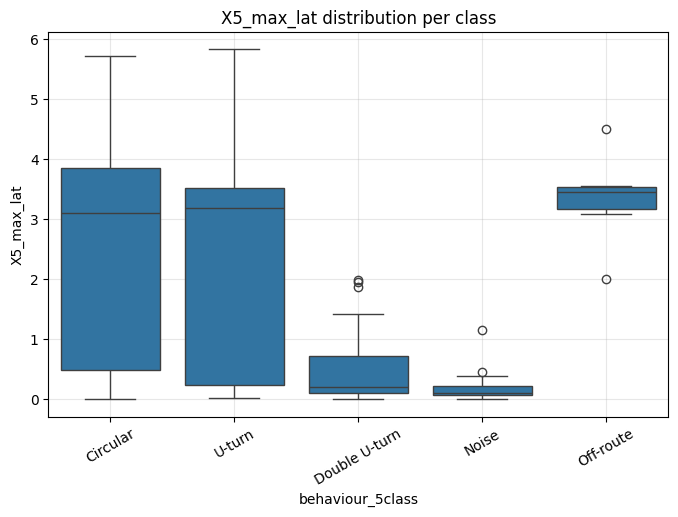

In [ ]:
import seaborn as sns

feat_cols = ['X1_std_sog','X2_detour',
             'X3_accum_cog','X4_delta_cog','X5_max_lat']

for col in feat_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='behaviour_5class', y=col,
                data=features_5)
    plt.title(f'{col} distribution per class')
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()

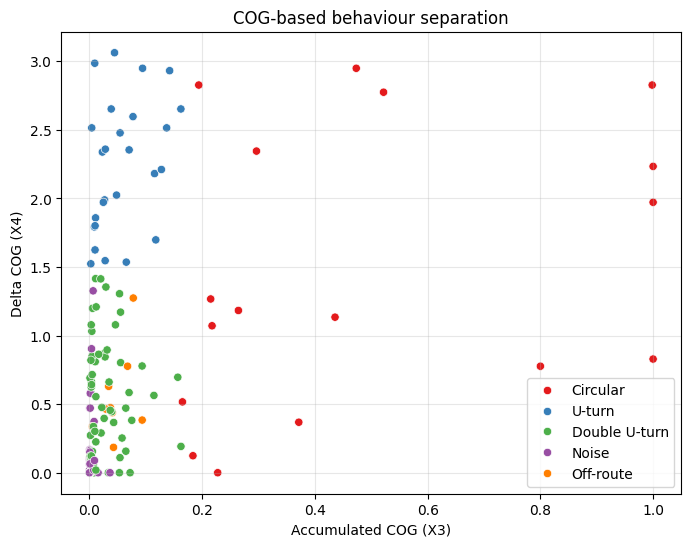

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=features_5['X3_accum_cog'],
    y=features_5['X4_delta_cog'],
    hue=features_5['behaviour_5class'],
    palette='Set1'
)

plt.xlabel('Accumulated COG (X3)')
plt.ylabel('Delta COG (X4)')
plt.title('COG-based behaviour separation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

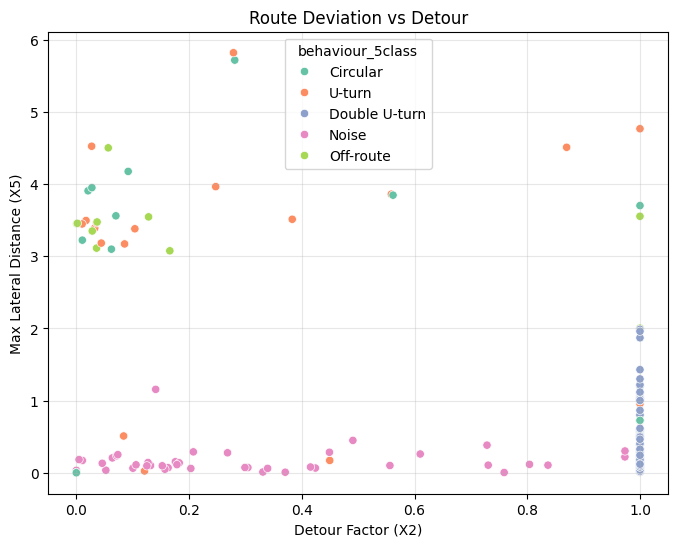

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=features_5['X2_detour'],
    y=features_5['X5_max_lat'],
    hue=features_5['behaviour_5class'],
    palette='Set2'
)

plt.xlabel('Detour Factor (X2)')
plt.ylabel('Max Lateral Distance (X5)')
plt.title('Route Deviation vs Detour')
plt.grid(alpha=0.3)
plt.show()

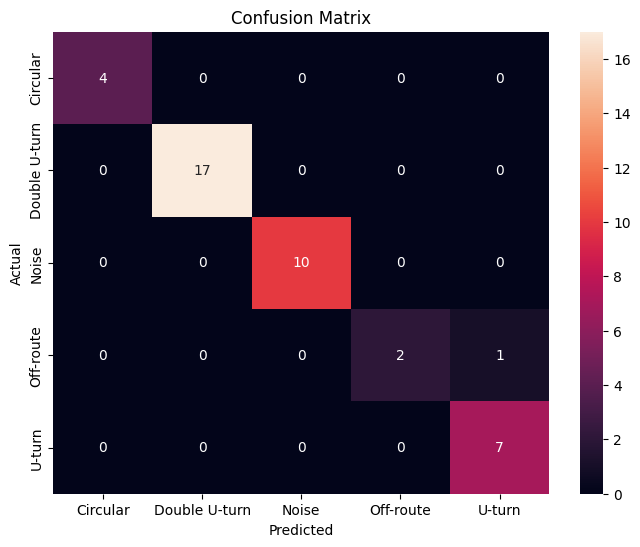

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm5, annot=True, fmt='d',
            xticklabels=le5.classes_,
            yticklabels=le5.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

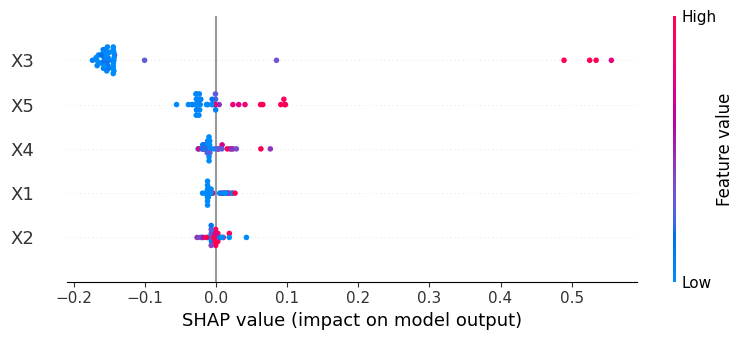

In [ ]:
import shap

shap.summary_plot(
    sv5[0],   # you can loop for all classes if needed
    X5_te,
    feature_names=['X1','X2','X3','X4','X5']
)

In [ ]:
# ── Overfitting check ─────────────────────────────────────────
train_acc = rf5.score(X5_tr, y5_tr)
test_acc  = rf5.score(X5_te, y5_te)
cv_acc    = grid5.best_score_

print("\n  Overfitting Check:")
print(f"  Training accuracy : {train_acc*100:.2f}%")
print(f"  CV accuracy       : {cv_acc*100:.2f}%")
print(f"  Test accuracy     : {test_acc*100:.2f}%")
print(f"  Train-Test gap    : {(train_acc-test_acc)*100:.2f}%")

if train_acc - test_acc > 0.10:
    print("  Status: OVERFITTING detected (gap > 10%)")
elif train_acc - test_acc > 0.05:
    print("  Status: SLIGHT overfitting (gap 5-10%)")
else:
    print("  Status: NORMAL FIT (gap < 5%) — no overfitting")


  Overfitting Check:
  Training accuracy : 100.00%
  CV accuracy       : 96.73%
  Test accuracy     : 97.56%
  Train-Test gap    : 2.44%
  Status: NORMAL FIT (gap < 5%) — no overfitting


In [ ]:
# ================================================================
# NOVELTY — BEHAVIOUR SEVERITY SCORE (FIXED)
# ================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("NOVELTY: Behaviour Severity Score (Fixed)")
print("=" * 60)

feat_cols = ['X1_std_sog','X2_detour',
             'X3_accum_cog','X4_delta_cog','X5_max_lat']

df_score = features_5.copy()

# ── Step 1: Normalise each feature to 0-1 ────────────────────
for col in feat_cols:
    col_min = df_score[col].min()
    col_max = df_score[col].max()
    if col_max > col_min:
        df_score[col+'_norm'] = (
            df_score[col] - col_min) / (col_max - col_min)
    else:
        df_score[col+'_norm'] = 0.0

# ── Step 2: Compute raw weighted score ───────────────────────
weights = {
    'X1_std_sog_norm'  : 0.20,
    'X2_detour_norm'   : 0.20,
    'X3_accum_cog_norm': 0.20,
    'X4_delta_cog_norm': 0.20,
    'X5_max_lat_norm'  : 0.20
}
raw_score = sum(df_score[col] * w
                for col, w in weights.items())

# ── Step 3: RESCALE to full 0-10 range ───────────────────────
# This guarantees at least one High Risk and one Low Risk
raw_min = raw_score.min()
raw_max = raw_score.max()
df_score['severity_score'] = (
    (raw_score - raw_min) / (raw_max - raw_min)
) * 10

print(f"  Score range after rescaling: "
      f"{df_score['severity_score'].min():.2f} – "
      f"{df_score['severity_score'].max():.2f}")

# ── Step 4: Risk labels using percentile thresholds ──────────
# Use top 20% = High Risk, bottom 30% = Low Risk, rest = Medium
high_thresh = df_score['severity_score'].quantile(0.80)
low_thresh  = df_score['severity_score'].quantile(0.30)

def risk_label(score):
    if score >= high_thresh:
        return 'High Risk'
    elif score >= low_thresh:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_score['risk_level'] = df_score[
    'severity_score'].apply(risk_label)

print(f"  High Risk threshold  : {high_thresh:.2f}")
print(f"  Low Risk threshold   : {low_thresh:.2f}")

# ── Print top 10 most severe ──────────────────────────────────
print(f"\n  Top 10 most severe abnormal segments:")
print(f"  {'MMSI':12s} {'Class':20s} "
      f"{'Score':>8s} {'Risk':>12s}")
print(f"  {'-'*56}")
top10 = df_score.nlargest(10, 'severity_score')
for _, row in top10.iterrows():
    print(f"  {str(row['MMSI']):12s} "
          f"{row['behaviour_5class']:20s} "
          f"{row['severity_score']:>8.2f} "
          f"{row['risk_level']:>12s}")

# ── Mean severity per class ───────────────────────────────────
print(f"\n  Mean severity score per class:")
mean_sev = df_score.groupby(
    'behaviour_5class')['severity_score'].mean()
for cls, score in mean_sev.sort_values(
        ascending=False).items():
    print(f"    {cls:20s} : {score:.2f} / 10")

# ── Risk distribution ─────────────────────────────────────────
print(f"\n  Risk level distribution:")
risk_counts = df_score['risk_level'].value_counts()
for risk, cnt in risk_counts.items():
    pct = cnt/len(df_score)*100
    print(f"    {risk:15s} : {cnt:4d} ({pct:.1f}%)")

# ── Validation check ──────────────────────────────────────────
print(f"\n  Validation check:")
print(f"    Total segments scored : {len(df_score)}")
print(f"    Score range           : "
      f"{df_score['severity_score'].min():.2f} – "
      f"{df_score['severity_score'].max():.2f}")
print(f"    All 5 classes present : "
      f"{sorted(df_score['behaviour_5class'].unique())}")
print(f"    Risk levels present   : "
      f"{sorted(df_score['risk_level'].unique())}")

high_risk = df_score[df_score['risk_level']=='High Risk']
low_risk  = df_score[df_score['risk_level']=='Low Risk']
print(f"    Mean score High Risk  : "
      f"{high_risk['severity_score'].mean():.2f}")
print(f"    Mean score Low Risk   : "
      f"{low_risk['severity_score'].mean():.2f}")

if high_risk['severity_score'].mean() > \
   low_risk['severity_score'].mean():
    print(f"    Status: CORRECT — High Risk > Low Risk")
else:
    print(f"    Status: WARNING — check scoring logic")

# ── Plot 1: Box plot + Risk bar ───────────────────────────────
colors_map = {
    'Circular'     : 'gold',
    'U-turn'       : 'darkorange',
    'Off-route'    : 'red',
    'Double U-turn': 'steelblue',
    'Noise'        : 'grey'
}
classes = ['Circular','U-turn','Off-route',
           'Double U-turn','Noise']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Behaviour Severity Score Analysis (Novelty)',
             fontsize=13)

data_box = [
    df_score[df_score['behaviour_5class']==cls][
        'severity_score'].values
    for cls in classes
]
bp = axes[0].boxplot(data_box, labels=classes,
                     patch_artist=True)
for patch, cls in zip(bp['boxes'], classes):
    patch.set_facecolor(colors_map.get(cls, 'grey'))
    patch.set_alpha(0.7)
axes[0].axhline(y=high_thresh, color='red',
                ls='--', lw=1.5,
                label=f'High risk ≥ {high_thresh:.1f}')
axes[0].axhline(y=low_thresh, color='orange',
                ls='--', lw=1.5,
                label=f'Low risk < {low_thresh:.1f}')
axes[0].set_title('Severity score per behaviour class')
axes[0].set_ylabel('Severity score (0–10)')
axes[0].set_xticklabels(classes, rotation=15,
                         ha='right', fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

risk_order  = ['High Risk', 'Medium Risk', 'Low Risk']
risk_colors = ['red', 'orange', 'green']
risk_vals   = [risk_counts.get(r, 0) for r in risk_order]
bars = axes[1].bar(risk_order, risk_vals,
                   color=risk_colors, alpha=0.8,
                   edgecolor='white')
for bar, val in zip(bars, risk_vals):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        str(val), ha='center', va='bottom', fontsize=11)
axes[1].set_title('Risk level distribution')
axes[1].set_ylabel('Number of segments')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: Scatter severity vs max lateral distance ─────────
fig, ax = plt.subplots(figsize=(10, 7))
for cls in classes:
    mask = df_score['behaviour_5class'] == cls
    ax.scatter(
        df_score.loc[mask, 'X5_max_lat'],
        df_score.loc[mask, 'severity_score'],
        s=50, color=colors_map.get(cls,'black'),
        alpha=0.75, label=cls, edgecolors='white',
        linewidths=0.5
    )
ax.axhline(y=high_thresh, color='red', ls='--',
           lw=1.5, label=f'High risk ({high_thresh:.1f})')
ax.axhline(y=low_thresh, color='orange', ls='--',
           lw=1.5, label=f'Low risk ({low_thresh:.1f})')
ax.set_xlabel('Max lateral distance (X5)', fontsize=11)
ax.set_ylabel('Severity score (0–10)', fontsize=11)
ax.set_title('Severity score vs Max lateral distance',
             fontsize=13)
ax.legend(title='Behaviour class', fontsize=9,
          loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 3: Severity score histogram ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_score['severity_score'], bins=20,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(x=high_thresh, color='red', ls='--',
           lw=2, label=f'High Risk ≥ {high_thresh:.1f}')
ax.axvline(x=low_thresh, color='orange', ls='--',
           lw=2, label=f'Low Risk < {low_thresh:.1f}')
ax.set_xlabel('Severity score (0–10)', fontsize=11)
ax.set_ylabel('Number of segments', fontsize=11)
ax.set_title('Overall severity score distribution '
             'across all abnormal segments', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n  Novelty complete — 3 plots shown above.")

NOVELTY: Behaviour Severity Score (Fixed)
  Score range after rescaling: 0.00 – 10.00
  High Risk threshold  : 5.32
  Low Risk threshold   : 3.29

  Top 10 most severe abnormal segments:
  MMSI         Class                   Score         Risk
  --------------------------------------------------------
  240070000    Circular                10.00    High Risk
  267188530    U-turn                   9.85    High Risk
  219484000    Circular                 9.64    High Risk
  230186000    Circular                 9.18    High Risk
  267188530    U-turn                   8.71    High Risk
  235603000    U-turn                   8.59    High Risk
  298811848    U-turn                   8.27    High Risk
  256465000    Circular                 8.24    High Risk
  212363000    U-turn                   7.99    High Risk
  0            Circular                 7.72    High Risk

  Mean severity score per class:
    Circular             : 6.82 / 10
    U-turn               : 6.27 / 10
    Doub

/tmp/ipykernel_2992/4232627359.py:140: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_box, labels=classes,



  Novelty complete — 3 plots shown above.


/tmp/ipykernel_2992/1770913633.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


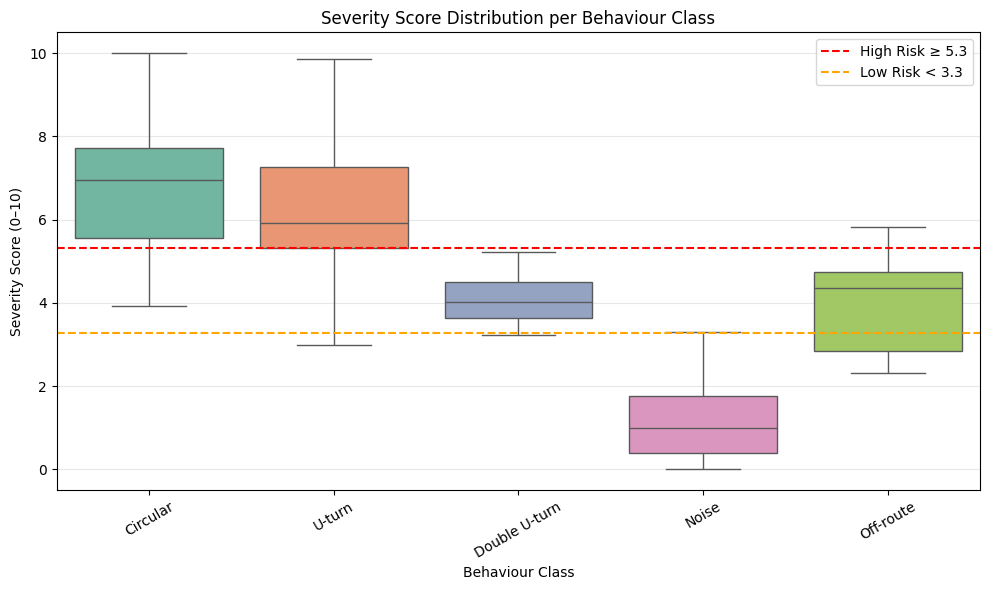

/tmp/ipykernel_2992/1770913633.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


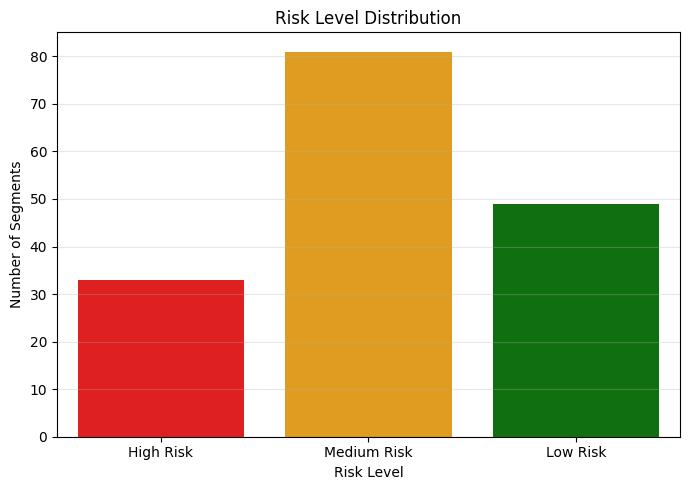

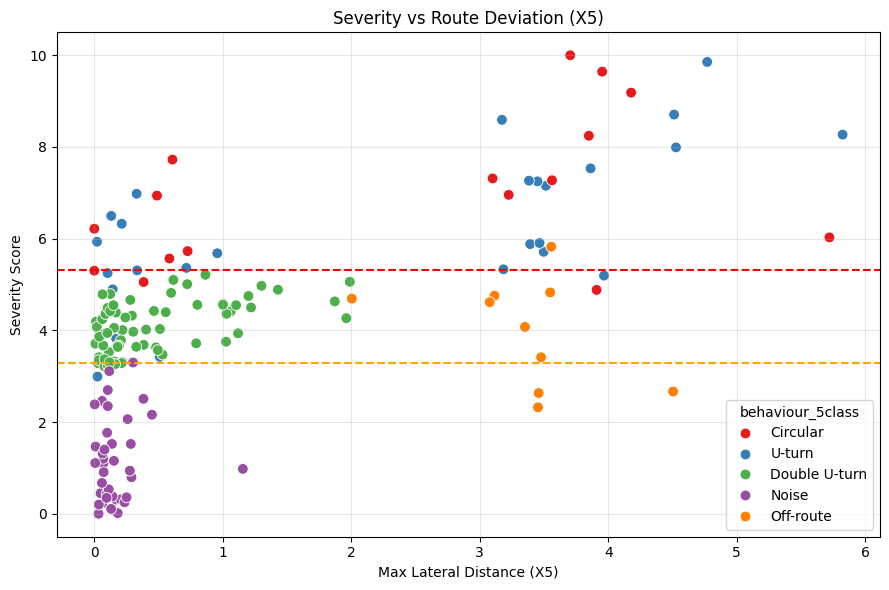

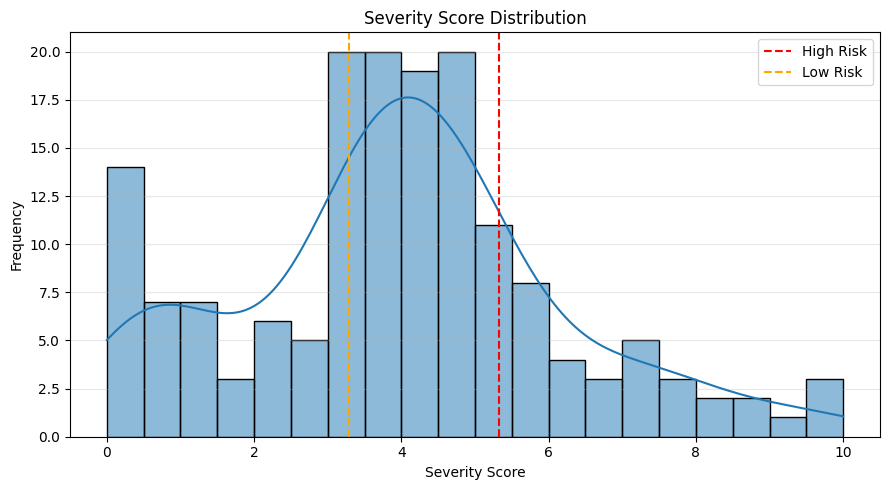

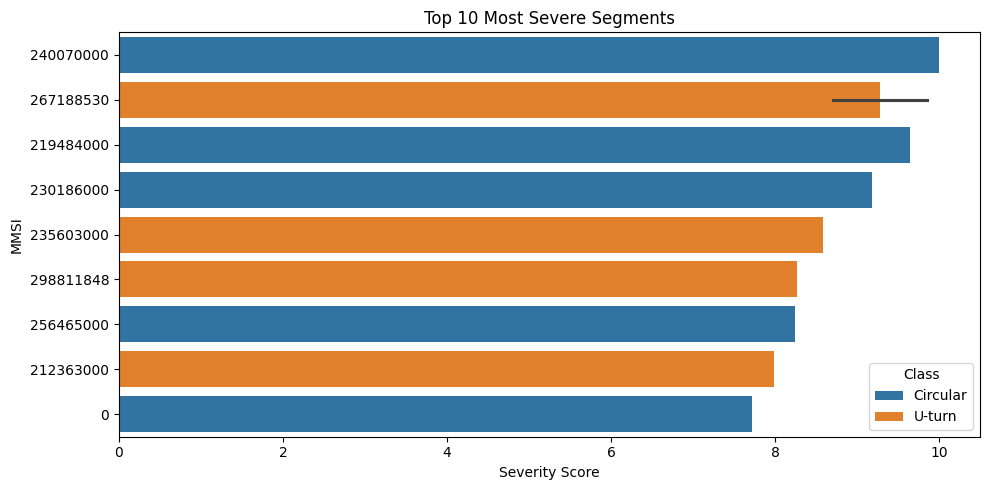

In [ ]:
# IMPORTANT (for Colab display)
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# PLOT 1 — BOX PLOT (CLASS vs SEVERITY) + RISK LINES
# =========================================================
plt.figure(figsize=(10,6))

sns.boxplot(
    x='behaviour_5class',
    y='severity_score',
    data=df_score,
    palette='Set2'
)

plt.axhline(high_thresh, color='red', linestyle='--',
            label=f'High Risk ≥ {high_thresh:.1f}')
plt.axhline(low_thresh, color='orange', linestyle='--',
            label=f'Low Risk < {low_thresh:.1f}')

plt.title('Severity Score Distribution per Behaviour Class')
plt.xlabel('Behaviour Class')
plt.ylabel('Severity Score (0–10)')
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 2 — RISK LEVEL DISTRIBUTION (BAR)
# =========================================================
plt.figure(figsize=(7,5))

sns.countplot(
    x='risk_level',
    data=df_score,
    order=['High Risk','Medium Risk','Low Risk'],
    palette=['red','orange','green']
)

plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Segments')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 3 — SCATTER (SEVERITY vs X5 MAX LAT DIST)
# =========================================================
plt.figure(figsize=(9,6))

sns.scatterplot(
    x='X5_max_lat',
    y='severity_score',
    hue='behaviour_5class',
    data=df_score,
    palette='Set1',
    s=60
)

plt.axhline(high_thresh, color='red', linestyle='--')
plt.axhline(low_thresh, color='orange', linestyle='--')

plt.title('Severity vs Route Deviation (X5)')
plt.xlabel('Max Lateral Distance (X5)')
plt.ylabel('Severity Score')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# PLOT 4 — HISTOGRAM (OVERALL SEVERITY)
# =========================================================
plt.figure(figsize=(9,5))

sns.histplot(
    df_score['severity_score'],
    bins=20,
    kde=True
)

plt.axvline(high_thresh, color='red', linestyle='--',
            label='High Risk')
plt.axvline(low_thresh, color='orange', linestyle='--',
            label='Low Risk')

plt.title('Severity Score Distribution')
plt.xlabel('Severity Score')
plt.ylabel('Frequency')
plt.legend()

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# 🔥 PLOT 5 — TOP 10 MOST SEVERE SEGMENTS (VERY IMPRESSIVE)
# =========================================================
top10 = df_score.nlargest(10, 'severity_score')

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10['severity_score'],
    y=top10['MMSI'].astype(str),
    hue=top10['behaviour_5class'],
    dodge=False
)

plt.title('Top 10 Most Severe Segments')
plt.xlabel('Severity Score')
plt.ylabel('MMSI')
plt.legend(title='Class')

plt.tight_layout()
plt.show()

In [ ]:
# ── Novelty validation check ──────────────────────────────────
print("Novelty output validation:")
print(f"  Total segments scored    : {len(df_score)}")
print(f"  Score range              : "
      f"{df_score['severity_score'].min():.2f} – "
      f"{df_score['severity_score'].max():.2f}")
print(f"  Expected range           : 0.0 – 10.0")

# Check all 5 classes are represented
classes_present = df_score['behaviour_5class'].unique()
print(f"  Classes in scored data   : {sorted(classes_present)}")

# Check risk levels are assigned
print(f"  Risk levels assigned     : "
      f"{sorted(df_score['risk_level'].unique())}")

# Verify high severity = high feature values
high_risk = df_score[df_score['risk_level']=='High Risk']
low_risk  = df_score[df_score['risk_level']=='Low Risk']
print(f"\n  Mean score — High Risk   : "
      f"{high_risk['severity_score'].mean():.2f}")
print(f"  Mean score — Low Risk    : "
      f"{low_risk['severity_score'].mean():.2f}")

if high_risk['severity_score'].mean() > \
   low_risk['severity_score'].mean():
    print(f"\n  Novelty output is CORRECT")
    print(f"  High risk segments have higher scores than "
          f"low risk — as expected")
else:
    print(f"\n  Warning: check scoring logic")

Novelty output validation:
  Total segments scored    : 163
  Score range              : 0.00 – 10.00
  Expected range           : 0.0 – 10.0
  Classes in scored data   : ['Circular', 'Double U-turn', 'Noise', 'Off-route', 'U-turn']
  Risk levels assigned     : ['High Risk', 'Low Risk', 'Medium Risk']

  Mean score — High Risk   : 7.12
  Mean score — Low Risk    : 1.48

  Novelty output is CORRECT
  High risk segments have higher scores than low risk — as expected


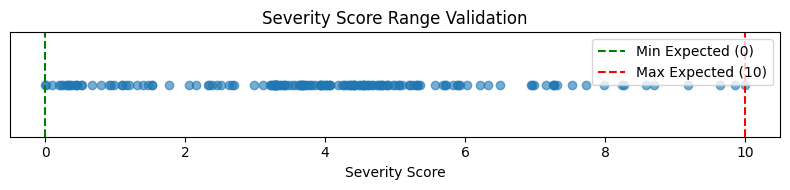

/tmp/ipykernel_2992/4066303868.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


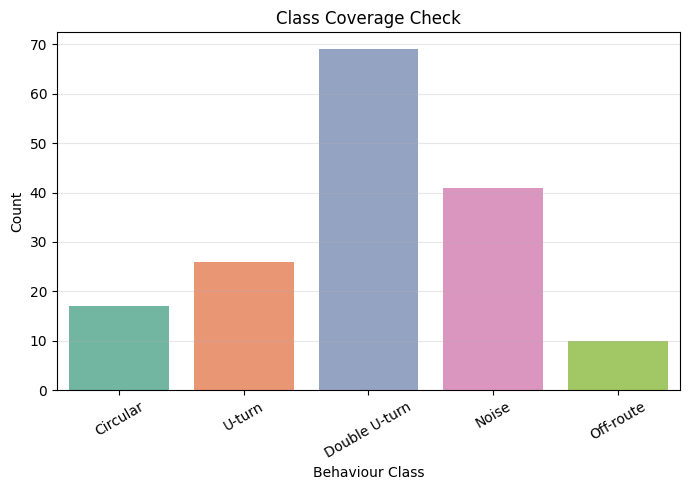

/tmp/ipykernel_2992/4066303868.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


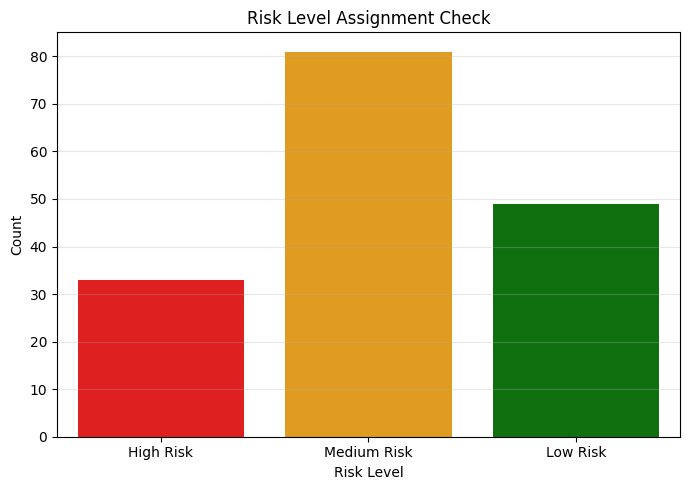

/tmp/ipykernel_2992/4066303868.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


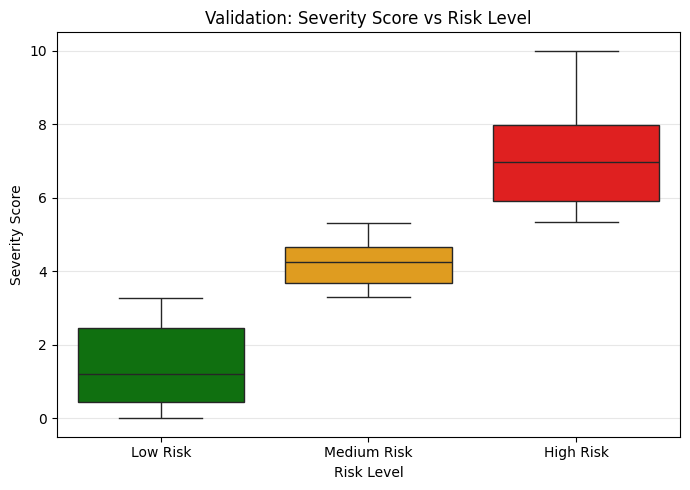

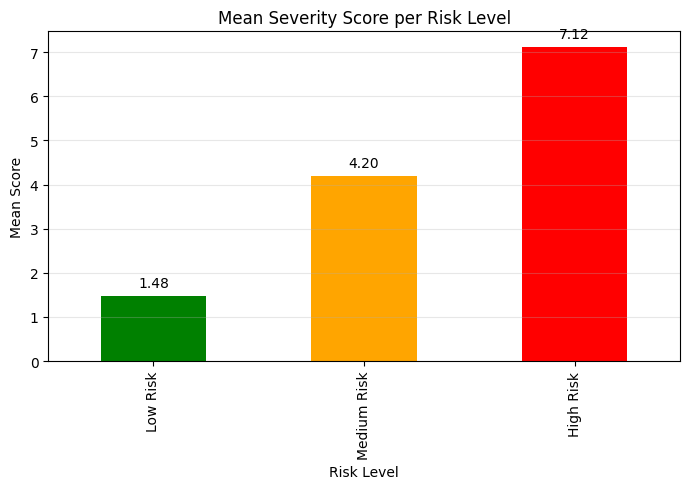

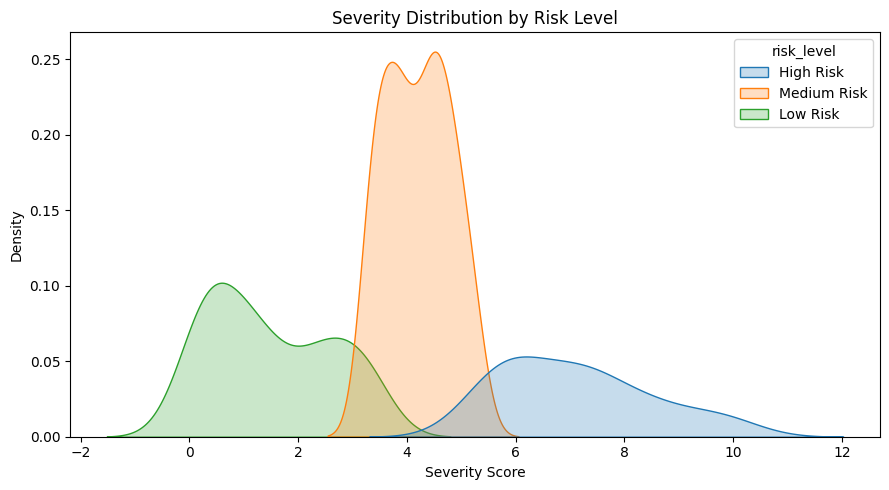

In [ ]:
# IMPORTANT (for Colab)
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# 1. SCORE RANGE VALIDATION (MIN–MAX VISUAL)
# =========================================================
plt.figure(figsize=(8,2))

plt.scatter(df_score['severity_score'],
            np.zeros(len(df_score)),
            alpha=0.6)

plt.axvline(0, color='green', linestyle='--', label='Min Expected (0)')
plt.axvline(10, color='red', linestyle='--', label='Max Expected (10)')

plt.title('Severity Score Range Validation')
plt.xlabel('Severity Score')
plt.yticks([])
plt.legend()

plt.tight_layout()
plt.show()


# =========================================================
# 2. CLASS COVERAGE (ALL 5 CLASSES PRESENT)
# =========================================================
plt.figure(figsize=(7,5))

sns.countplot(
    x='behaviour_5class',
    data=df_score,
    palette='Set2'
)

plt.title('Class Coverage Check')
plt.xlabel('Behaviour Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# 3. RISK LEVEL VALIDATION
# =========================================================
plt.figure(figsize=(7,5))

sns.countplot(
    x='risk_level',
    data=df_score,
    order=['High Risk','Medium Risk','Low Risk'],
    palette=['red','orange','green']
)

plt.title('Risk Level Assignment Check')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# 4. 🔥 KEY VALIDATION — HIGH vs LOW SCORE COMPARISON
# =========================================================
plt.figure(figsize=(7,5))

sns.boxplot(
    x='risk_level',
    y='severity_score',
    data=df_score,
    order=['Low Risk','Medium Risk','High Risk'],
    palette=['green','orange','red']
)

plt.title('Validation: Severity Score vs Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Severity Score')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# 5. MEAN SCORE COMPARISON (VERY CLEAR PROOF)
# =========================================================
mean_scores = df_score.groupby('risk_level')['severity_score'].mean()

plt.figure(figsize=(7,5))

mean_scores.loc[['Low Risk','Medium Risk','High Risk']].plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title('Mean Severity Score per Risk Level')
plt.ylabel('Mean Score')
plt.xlabel('Risk Level')

for i, val in enumerate(mean_scores.loc[['Low Risk','Medium Risk','High Risk']]):
    plt.text(i, val + 0.2, f"{val:.2f}", ha='center')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# 6. 🔥 DISTRIBUTION OVERLAP (STRONG VALIDATION)
# =========================================================
plt.figure(figsize=(9,5))

sns.kdeplot(
    data=df_score,
    x='severity_score',
    hue='risk_level',
    fill=True
)

plt.title('Severity Distribution by Risk Level')
plt.xlabel('Severity Score')
plt.ylabel('Density')

plt.tight_layout()
plt.show()